In [1]:
import os
os.environ.setdefault("LEAPS_EMG_H5", "/home/nadinebadie/lalitha/datasets/emg_activations_v2.h5")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA, NMF, FastICA

from leaps.data.metadata import LEAPS_H5_PATH
from leaps.data.stride_dataset import load_strides, stride_train_val_split

torch.set_num_threads(1)

def r2(x, x_hat):
    ss_res = ((x - x_hat) ** 2).sum()
    ss_tot = ((x - x.mean(axis=0)) ** 2).sum()
    return 1 - ss_res / ss_tot

# ---------------------------------------------------------------------------
# Data: treadmill only, all subjects pooled, subject-level held-out split
# ---------------------------------------------------------------------------
strides, meta = load_strides(LEAPS_H5_PATH, with_metadata=True)
strides_train, strides_val, meta_train, meta_val = stride_train_val_split(strides, meta, val_fraction=0.2, seed=42)

train_tm_mask = meta_train["modes"] == "treadmill"
val_tm_mask   = meta_val["modes"] == "treadmill"
strides_train_tm = strides_train[train_tm_mask]
X_val_tm = strides_val[val_tm_mask].reshape(-1, 11).astype(np.float32)

X_train_tm_all = strides_train_tm.reshape(-1, 11)
p01 = np.percentile(X_train_tm_all, 1, axis=0)
p99 = np.percentile(X_train_tm_all, 99, axis=0)

def to_unit(x):
    return np.clip((x - p01) / (p99 - p01 + 1e-8), 0, 1).astype(np.float32)

def from_unit(x):
    return (x * (p99 - p01 + 1e-8) + p01).astype(np.float32)

X_val_tm_u = to_unit(X_val_tm)

# same 50k-frame subsample used for every method, for a fair comparison
rng_sub = np.random.default_rng(0)
X_train_tm_all_u = to_unit(X_train_tm_all)
sub_idx = rng_sub.choice(len(X_train_tm_all_u), size=50_000, replace=False)
X_train_u = X_train_tm_all_u[sub_idx]

# ---------------------------------------------------------------------------
# Finalized AE architecture + loss (tanh hidden, linear latent, sigmoid
# output, Lnorm penalty threshold=0.5 / scale=0.6)
# ---------------------------------------------------------------------------
class AE_TanhHidden_LinearLatent_SigmoidOutput(nn.Module):
    def __init__(self, dim_a, dim_latent):
        super().__init__()
        h = 2 * dim_latent
        self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.Tanh(), nn.Linear(h, dim_latent))
        self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.Tanh(), nn.Linear(h, dim_a), nn.Sigmoid())
    def forward(self, a):
        z = self.encoder(a)
        return self.decoder(z), z

def latent_norm_penalty(a_l, threshold=0.5, scale=0.6):
    near = a_l.abs()
    worst = near.max(dim=-1).values
    penalty = torch.where(worst < threshold, torch.zeros_like(worst), torch.exp((worst / scale) ** 10) - 1.0)
    return penalty.mean()

def train_ae(X_train, dim_latent, epochs=100, batch_size=512, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    model = AE_TanhHidden_LinearLatent_SigmoidOutput(dim_a=11, dim_latent=dim_latent)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(torch.from_numpy(X_train)), batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        for (batch,) in loader:
            a_hat, a_l = model(batch)
            loss = ((batch - a_hat) ** 2).sum(dim=-1).mean() + latent_norm_penalty(a_l)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

# ---------------------------------------------------------------------------
# Sweep K=1..11 for all four methods, same training subsample, same held-out set
# ---------------------------------------------------------------------------
K_VALUES = list(range(1, 12))
rows = []

# ICA needs its own subsample of the (already subsampled) training set, per your notebook's convention
rng_ica = np.random.default_rng(42)
ica_sub_idx = rng_ica.choice(len(X_train_u), size=min(20_000, len(X_train_u)), replace=False)
X_train_ica_sub = X_train_u[ica_sub_idx]

for K in K_VALUES:
    # PCA
    pca = PCA(n_components=K)
    pca.fit(X_train_u)
    W = pca.components_
    X_hat = ((X_val_tm_u - pca.mean_) @ W.T) @ W + pca.mean_
    rows.append({"K": K, "method": "PCA", "held_out_R2": r2(X_val_tm_u, X_hat)})

    # NMF (data already in [0,1], no clipping needed)
    nmf = NMF(n_components=K, init="nndsvda", max_iter=500, random_state=42)
    nmf.fit(X_train_u)
    X_hat = nmf.inverse_transform(nmf.transform(X_val_tm_u))
    rows.append({"K": K, "method": "NMF", "held_out_R2": r2(X_val_tm_u, X_hat)})

    # ICA
    ica = FastICA(n_components=K, random_state=42, max_iter=500)
    ica.fit(X_train_ica_sub)
    X_hat = ica.inverse_transform(ica.transform(X_val_tm_u))
    rows.append({"K": K, "method": "ICA", "held_out_R2": r2(X_val_tm_u, X_hat)})

    # AE, finalized architecture + penalty
    model = train_ae(X_train_u, dim_latent=K, epochs=100, batch_size=512, seed=0)
    model.eval()
    with torch.no_grad():
        val_hat_u, _ = model(torch.from_numpy(X_val_tm_u))
    rows.append({"K": K, "method": "AE", "held_out_R2": r2(X_val_tm_u, val_hat_u.numpy())})

    print(f"K={K} done: " + ", ".join(f"{r['method']}={r['held_out_R2']:.3f}" for r in rows[-4:]))

comparison_table = pd.DataFrame(rows).pivot(index="K", columns="method", values="held_out_R2")
comparison_table = comparison_table[["PCA", "ICA", "NMF", "AE"]]
print()
print(comparison_table)


/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


K=1 done: PCA=0.287, NMF=0.210, ICA=0.287, AE=0.381
K=2 done: PCA=0.521, NMF=0.454, ICA=0.521, AE=0.648
K=3 done: PCA=0.678, NMF=0.612, ICA=0.678, AE=0.752
K=4 done: PCA=0.762, NMF=0.728, ICA=0.761, AE=0.826
K=5 done: PCA=0.832, NMF=0.804, ICA=0.833, AE=0.863
K=6 done: PCA=0.888, NMF=0.867, ICA=0.889, AE=0.901


/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


K=7 done: PCA=0.933, NMF=0.904, ICA=0.933, AE=0.921


/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


K=8 done: PCA=0.954, NMF=0.944, ICA=0.954, AE=0.951


/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


K=9 done: PCA=0.966, NMF=0.965, ICA=0.966, AE=0.967
K=10 done: PCA=0.988, NMF=0.989, ICA=0.988, AE=0.977
K=11 done: PCA=1.000, NMF=1.000, ICA=1.000, AE=0.985

method       PCA       ICA       NMF        AE
K                                             
1       0.286797  0.287035  0.209561  0.380930
2       0.520666  0.520718  0.454490  0.648328
3       0.678430  0.677714  0.612347  0.751752
4       0.761619  0.761328  0.727933  0.825760
5       0.832086  0.833046  0.803838  0.863042
6       0.888393  0.888675  0.867253  0.901277
7       0.932997  0.933401  0.903958  0.921111
8       0.953904  0.954116  0.944253  0.951296
9       0.965729  0.965716  0.965378  0.967440
10      0.987599  0.987593  0.989024  0.977345
11      1.000000  1.000000  0.999988  0.984767


In [3]:
import matplotlib.pyplot as plt
from leaps.data.metadata import EMG_CHANNELS

# fit/train all four methods at K=1 on the same data as above
K1 = 7

pca1 = PCA(n_components=K1); pca1.fit(X_train_u)
nmf1 = NMF(n_components=K1, init="nndsvda", max_iter=500, random_state=42); nmf1.fit(X_train_u)
ica1 = FastICA(n_components=K1, random_state=42, max_iter=500); ica1.fit(X_train_ica_sub)
ae1 = train_ae(X_train_u, dim_latent=K1, epochs=100, batch_size=512, seed=0); ae1.eval()

# one representative held-out stride (full 101-frame gait cycle), not just flattened frames
rep_stride_raw = strides_val[val_tm_mask][0]          # (101, 11)
rep_stride_u = to_unit(rep_stride_raw)

def pca_reconstruct(x_u):
    W = pca1.components_
    z = (x_u - pca1.mean_) @ W.T
    x_hat = z @ W + pca1.mean_
    weights = W[0]
    return z[:, 0], x_hat, weights

def nmf_reconstruct(x_u):
    z = nmf1.transform(x_u)
    x_hat = nmf1.inverse_transform(z)
    weights = nmf1.components_[0]   # NMF weights are non-negative by construction -- cannot show antagonist muscles
    return z[:, 0], x_hat, weights

def ica_reconstruct(x_u):
    z = ica1.transform(x_u)
    x_hat = ica1.inverse_transform(z)
    weights = ica1.mixing_.T[0]     # sign/scale are arbitrary for ICA
    return z[:, 0], x_hat, weights

def ae_reconstruct(x_u):
    with torch.no_grad():
        x_hat_t, z_t = ae1(torch.from_numpy(x_u))
    z = z_t.numpy()
    x_hat = x_hat_t.numpy()
    # nonlinear "weight" analog: effective per-muscle delta sweeping z over its observed range
    z_lo, z_hi = z.min(), z.max()
    with torch.no_grad():
        lo = ae1.decoder(torch.full((1, K1), z_lo))
        hi = ae1.decoder(torch.full((1, K1), z_hi))
    weights = (hi - lo).numpy().ravel()
    return z[:, 0], x_hat, weights

methods = [
    ("PCA", pca_reconstruct),
    ("ICA", ica_reconstruct),
    ("NMF (weights >= 0 only)", nmf_reconstruct),
    ("AE (nonlinear weight approx.)", ae_reconstruct),
]

gait_pct = np.linspace(0, 100, 101)
STACK_SPACING = 1.3  # vertical offset between muscle bands in the stacked activity plot

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
fig.suptitle("Synergy extraction, K=1, treadmill (all subjects pooled) -- one held-out stride", fontsize=13, fontweight="bold")

for row, (name, fn) in enumerate(methods):
    synergy_t, x_hat_u, weights = fn(rep_stride_u)

    ax_act = axes[row, 0]
    for c in range(11):
        offset = c * STACK_SPACING
        ax_act.axhline(offset, color="grey", lw=0.4, alpha=0.4)
        ax_act.plot(gait_pct, rep_stride_u[:, c] + offset, color="black", lw=0.8)
        ax_act.plot(gait_pct, x_hat_u[:, c] + offset, color="#1565C0", lw=1.0, ls="--")
    ax_act.set_yticks([c * STACK_SPACING for c in range(11)])
    ax_act.set_yticklabels(EMG_CHANNELS, fontsize=6)
    ax_act.set_title(f"{name}\nmuscle activity (black=real, blue=recon)", fontsize=9)
    ax_act.set_xlabel("Gait %")
    ax_act.set_ylim(-0.5, 10 * STACK_SPACING + 1.1)
    if row == 0:
        ax_act.plot([], [], color="black", lw=0.8, label="real")
        ax_act.plot([], [], color="#1565C0", lw=1.0, ls="--", label="recon")
        ax_act.legend(fontsize=6, loc="upper right")

    ax_syn = axes[row, 1]
    ax_syn.plot(gait_pct, synergy_t, color="#2E7D32", lw=1.5)
    ax_syn.axhline(0, color="black", lw=0.4, ls="--")
    ax_syn.set_title("synergy activation (K=1)", fontsize=9)
    ax_syn.set_xlabel("Gait %")

    ax_w = axes[row, 2]
    colors = ["#1565C0" if w >= 0 else "#C62828" for w in weights]   # blue=agonist(+), red=antagonist(-)
    ax_w.bar(range(11), weights, color=colors)
    ax_w.set_xticks(range(11))
    ax_w.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
    ax_w.set_title("muscle weights", fontsize=9)
    ax_w.axhline(0, color="black", lw=0.5)

plt.tight_layout()
plt.show()

NameError: name 'X_train_u' is not defined

In [1]:
import os
os.environ["LEAPS_EMG_H5"] = "/home/nadinebadie/lalitha/datasets/emg_activations_v2.h5"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from leaps.data.metadata import LEAPS_H5_PATH
from leaps.data.stride_dataset import load_strides, stride_train_val_split
from leaps.envs.emg_mapping import EMG_CHANNELS

strides, meta = load_strides(LEAPS_H5_PATH, with_metadata=True)
strides_train, strides_val, meta_train, meta_val = stride_train_val_split(strides, meta, val_fraction=0.2, seed=42)
X_train = strides_train.reshape(-1, 11).astype(np.float32)
X_val = strides_val.reshape(-1, 11).astype(np.float32)

In [2]:
def r2(x, x_hat):
    ss_res = ((x - x_hat) ** 2).sum()
    ss_tot = ((x - x.mean(axis=0)) ** 2).sum()
    return 1 - ss_res / ss_tot

## Rough work

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
torch.set_num_threads(1)

#autoencoder (1 layer sigmoids, tanh)
class LatentActionAESmall(nn.Module):
      def __init__(self, dim_a, dim_latent):
          super().__init__()
          h = 2 * dim_latent
          self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.Tanh(), nn.Linear(h, dim_latent), nn.Sigmoid())
          self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.Tanh(), nn.Linear(h, dim_a), nn.Sigmoid())

      def forward(self, a):
          a_l = self.encoder(a)
          return self.decoder(a_l), a_l


def train_ae(X_train, dim_latent, epochs=200, batch_size=32, lr=1e-3, seed=0):
      torch.manual_seed(seed)
      model = LatentActionAESmall(dim_a=X_train.shape[1], dim_latent=dim_latent)
      opt = torch.optim.Adam(model.parameters(), lr=lr)
      loader = DataLoader(TensorDataset(torch.from_numpy(X_train)), batch_size=batch_size, shuffle=True)
      for _ in range(epochs):
          for (batch,) in loader:
              a_hat, _ = model(batch)
              loss = ((batch - a_hat) ** 2).sum(dim=-1).mean()
              opt.zero_grad(); loss.backward(); opt.step()
      return model


In [4]:
strides, meta = load_strides(LEAPS_H5_PATH, with_metadata=True)
strides_train, strides_val, meta_train, meta_val = stride_train_val_split(strides, meta, val_fraction=0.2, seed=42)

train_tm_mask = meta_train["modes"] == "treadmill"
val_tm_mask   = meta_val["modes"] == "treadmill"

strides_train_tm = strides_train[train_tm_mask]                          # pool to draw single strides from
X_val_tm = strides_val[val_tm_mask].reshape(-1, 11).astype(np.float32)   # fixed held-out frames, unseen subjects

print(f"Treadmill training pool: {strides_train_tm.shape[0]} strides (all speeds pooled)")
print(f"Held-out treadmill frames (unseen subjects): {X_val_tm.shape[0]}")

# Percentile bounds from the FULL training pool (not the single stride)
X_train_tm_all = strides_train_tm.reshape(-1, 11)
p01 = np.percentile(X_train_tm_all, 1, axis=0)
p99 = np.percentile(X_train_tm_all, 99, axis=0)

def to_unit(x):
    return np.clip((x - p01) / (p99 - p01 + 1e-8), 0, 1).astype(np.float32)

def from_unit(x):
    return (x * (p99 - p01 + 1e-8) + p01).astype(np.float32)

X_val_tm_u = to_unit(X_val_tm)

Treadmill training pool: 15632 strides (all speeds pooled)
Held-out treadmill frames (unseen subjects): 328957


In [5]:

  # ablation1: train on ONE random stride, repeat 10x, sweep for K
  # Ablation: train on exactly ONE random stride, repeat 10x, sweep K

N_DRAWS = 10
K_VALUES = [4, 6, 8]

rng = np.random.default_rng(0)
draw_indices = rng.choice(len(strides_train_tm), size=N_DRAWS, replace=False)

rows = []
for draw_i, stride_idx in enumerate(draw_indices):
    single_stride = strides_train_tm[stride_idx]     # (101, 11) -- ONE gait cycle
    X_train_one = to_unit(single_stride)

    for k in K_VALUES:
          model = train_ae(X_train_one, dim_latent=k, epochs=200, batch_size=32, seed=draw_i)
          model.eval()
          with torch.no_grad():
              val_hat_u, _ = model(torch.from_numpy(X_val_tm_u))
          val_hat = from_unit(val_hat_u.numpy())
          held_out_r2 = r2(X_val_tm, val_hat)
          rows.append({"draw": draw_i, "stride_idx": int(stride_idx), "K": k, "held_out_R2": held_out_r2})
          print(f"draw {draw_i} (stride {stride_idx}) K={k} held_out_R2={held_out_r2:.3f}")

single_stride_table = pd.DataFrame(rows)

summary = single_stride_table.groupby("K")["held_out_R2"].agg(["mean", "std"]).rename(
      columns={"mean": "held_out_R2_mean", "std": "held_out_R2_std"})
print("\n=== Single-stride AE, treadmill (all speeds pooled), 10 draws ===")
print(summary)

/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


draw 0 (stride 13289) K=4 held_out_R2=-0.131
draw 0 (stride 13289) K=6 held_out_R2=-0.112
draw 0 (stride 13289) K=8 held_out_R2=0.109
draw 1 (stride 12713) K=4 held_out_R2=-0.124
draw 1 (stride 12713) K=6 held_out_R2=0.092
draw 1 (stride 12713) K=8 held_out_R2=0.132
draw 2 (stride 9951) K=4 held_out_R2=-0.144
draw 2 (stride 9951) K=6 held_out_R2=-0.138
draw 2 (stride 9951) K=8 held_out_R2=-0.130
draw 3 (stride 7986) K=4 held_out_R2=-0.211
draw 3 (stride 7986) K=6 held_out_R2=-0.226
draw 3 (stride 7986) K=8 held_out_R2=-0.235
draw 4 (stride 4215) K=4 held_out_R2=-0.203
draw 4 (stride 4215) K=6 held_out_R2=-0.209
draw 4 (stride 4215) K=8 held_out_R2=-0.224
draw 5 (stride 640) K=4 held_out_R2=0.146
draw 5 (stride 640) K=6 held_out_R2=0.151
draw 5 (stride 640) K=8 held_out_R2=0.281
draw 6 (stride 258) K=4 held_out_R2=0.112
draw 6 (stride 258) K=6 held_out_R2=0.208
draw 6 (stride 258) K=8 held_out_R2=0.190
draw 7 (stride 4810) K=4 held_out_R2=-0.224
draw 7 (stride 4810) K=6 held_out_R2=-0.2

In [6]:
 #ablation2: train on ALL strides from ONE (subject, speed) condition
subjects_train_tm = meta_train["subjects"][train_tm_mask]
speeds_train_tm   = meta_train["speeds"][train_tm_mask]

combo_df = pd.DataFrame({"subject": subjects_train_tm, "speed": speeds_train_tm})
combo_counts = combo_df.value_counts().reset_index(name="n_strides")
combo_counts = combo_counts[combo_counts["n_strides"] >= 15]   # well-populated conditions only

print(f"{len(combo_counts)} (subject, speed) conditions with >=15 strides available")

N_DRAWS = 10
K_VALUES = [4, 6, 8]

rng = np.random.default_rng(1)
draw_rows = rng.choice(len(combo_counts), size=N_DRAWS, replace=False)

rows = []
for draw_i, row_i in enumerate(draw_rows):
      subj, speed, n_avail = combo_counts.iloc[row_i][["subject", "speed", "n_strides"]]
      cond_mask = (subjects_train_tm == subj) & (speeds_train_tm == speed)
      cond_strides = strides_train_tm[cond_mask]              # (n_strides, 101, 11) -- ONE condition
      X_train_cond = to_unit(cond_strides.reshape(-1, 11))

      for k in K_VALUES:
          model = train_ae(X_train_cond, dim_latent=k, epochs=200, batch_size=32, seed=draw_i)
          model.eval()
          with torch.no_grad():
              val_hat_u, _ = model(torch.from_numpy(X_val_tm_u))
          val_hat = from_unit(val_hat_u.numpy())
          held_out_r2 = r2(X_val_tm, val_hat)
          rows.append({"draw": draw_i, "subject": subj, "speed": speed,
                       "n_strides": int(n_avail), "K": k, "held_out_R2": held_out_r2})
          print(f"draw {draw_i} ({subj}, {speed} m/s, n={int(n_avail)} strides) K={k} held_out_R2={held_out_r2:.3f}")

condition_table = pd.DataFrame(rows)

summary_cond = condition_table.groupby("K")["held_out_R2"].agg(["mean", "std"]).rename(
      columns={"mean": "held_out_R2_mean", "std": "held_out_R2_std"})
print("\n=== One-condition AE (1 subject, 1 speed, ~15-40 strides), treadmill, 10 draws ===")
print(summary_cond)

481 (subject, speed) conditions with >=15 strides available
draw 0 (AB13, 1.6499999999999995 m/s, n=32 strides) K=4 held_out_R2=0.587
draw 0 (AB13, 1.6499999999999995 m/s, n=32 strides) K=6 held_out_R2=0.804
draw 0 (AB13, 1.6499999999999995 m/s, n=32 strides) K=8 held_out_R2=0.878
draw 1 (AB11, 1.05 m/s, n=25 strides) K=4 held_out_R2=0.521
draw 1 (AB11, 1.05 m/s, n=25 strides) K=6 held_out_R2=0.709
draw 1 (AB11, 1.05 m/s, n=25 strides) K=8 held_out_R2=0.752
draw 2 (AB15, 1.3500000000000003 m/s, n=18 strides) K=4 held_out_R2=0.542
draw 2 (AB15, 1.3500000000000003 m/s, n=18 strides) K=6 held_out_R2=0.742
draw 2 (AB15, 1.3500000000000003 m/s, n=18 strides) K=8 held_out_R2=0.802
draw 3 (AB11, 1.75 m/s, n=39 strides) K=4 held_out_R2=0.475
draw 3 (AB11, 1.75 m/s, n=39 strides) K=6 held_out_R2=0.798
draw 3 (AB11, 1.75 m/s, n=39 strides) K=8 held_out_R2=0.841
draw 4 (AB28, 1.3500000000000003 m/s, n=15 strides) K=4 held_out_R2=0.415
draw 4 (AB28, 1.3500000000000003 m/s, n=15 strides) K=6 held_o

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

#data is subject-level train/val split (seed=42), treadmill only

strides, meta = load_strides(LEAPS_H5_PATH, with_metadata=True)
strides_train, strides_val, meta_train, meta_val = stride_train_val_split(
      strides, meta, val_fraction=0.2, seed=42
  )

train_tm_mask = meta_train["modes"] == "treadmill"
val_tm_mask   = meta_val["modes"] == "treadmill"

strides_train_tm  = strides_train[train_tm_mask]
subjects_train_tm = meta_train["subjects"][train_tm_mask]
speeds_train_tm   = meta_train["speeds"][train_tm_mask]

X_val_tm = strides_val[val_tm_mask].reshape(-1, 11).astype(np.float32)

#%ile bounds from the full treadmill training pool
X_train_tm_all = strides_train_tm.reshape(-1, 11)
p01 = np.percentile(X_train_tm_all, 1, axis=0)
p99 = np.percentile(X_train_tm_all, 99, axis=0)

def to_unit(x):
      return np.clip((x - p01) / (p99 - p01 + 1e-8), 0, 1).astype(np.float32)

def from_unit(x):
      return (x * (p99 - p01 + 1e-8) + p01).astype(np.float32)

X_val_tm_u = to_unit(X_val_tm)

In [17]:
#pick one (subject, speed) condition (seed=1, draw index 0)

combo_df = pd.DataFrame({"subject": subjects_train_tm, "speed": speeds_train_tm})
combo_counts = combo_df.value_counts().reset_index(name="n_strides")
combo_counts = combo_counts[combo_counts["n_strides"] >= 15].reset_index(drop=True)

CONDITION_SEED = 1
N_DRAWS = 10
DRAW_INDEX = 0   # which of the 10 draws to use here

rng = np.random.default_rng(CONDITION_SEED)
draw_rows = rng.choice(len(combo_counts), size=N_DRAWS, replace=False)

subj, speed, n_avail = combo_counts.iloc[draw_rows[DRAW_INDEX]][["subject", "speed", "n_strides"]]
cond_mask = (subjects_train_tm == subj) & (speeds_train_tm == speed)
cond_strides = strides_train_tm[cond_mask]
X_train_cond = to_unit(cond_strides.reshape(-1, 11))
print(f"condition: subject={subj}, speed={speed} m/s, n_strides={cond_strides.shape[0]}, n_frames={X_train_cond.shape[0]}")

condition: subject=AB13, speed=1.6499999999999995 m/s, n_strides=32, n_frames=3232


In [18]:
#ae1
class AE_Sigmoid(nn.Module):
      """tanh hidden, sigmoid latent, sigmoid output."""
      def __init__(self, dim_a, dim_latent):
          super().__init__()
          h = 2 * dim_latent
          self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.Tanh(), nn.Linear(h, dim_latent), nn.Sigmoid())
          self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.Tanh(), nn.Linear(h, dim_a), nn.Sigmoid())
      def forward(self, a):
          z = self.encoder(a)
          return self.decoder(z), z


class AE_NoSigmoid(nn.Module):
      """relu hidden, no sigmoid anywhere - plain MSE."""
      def __init__(self, dim_a, dim_latent):
          super().__init__()
          h = 2 * dim_latent
          self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.ReLU(), nn.Linear(h, dim_latent))
          self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.ReLU(), nn.Linear(h, dim_a))
      def forward(self, a):
          z = self.encoder(a)
          return self.decoder(z), z


def train_simple(model, X_train, epochs=200, batch_size=32, lr=1e-3, seed=0):
      torch.manual_seed(seed)
      opt = torch.optim.Adam(model.parameters(), lr=lr)
      loader = DataLoader(TensorDataset(torch.from_numpy(X_train)), batch_size=batch_size, shuffle=True)
      for _ in range(epochs):
          for (batch,) in loader:
              a_hat, _ = model(batch)
              loss = ((batch - a_hat) ** 2).sum(dim=-1).mean()
              opt.zero_grad(); loss.backward(); opt.step()
      return model

In [19]:
K_VALUES = list(range(1, 12))
MODEL_SEED = 0

rows = []
for name, ModelCls in [("A: tanh+sigmoid (current)", AE_Sigmoid),
                          ("B: relu, no sigmoid (plain MSE)", AE_NoSigmoid)]:
      for K in K_VALUES:
          torch.manual_seed(MODEL_SEED)
          model = ModelCls(dim_a=11, dim_latent=K)
          model = train_simple(model, X_train_cond, epochs=200, seed=MODEL_SEED)
          model.eval()
          with torch.no_grad():
              val_hat_u, z_val = model(torch.from_numpy(X_val_tm_u))
          val_hat_u_np = val_hat_u.numpy()
          val_hat = from_unit(val_hat_u_np)
          held_out_r2 = r2(X_val_tm, val_hat)

          rows.append({
              "model": name,
              "K": K,
              "held_out_R2": held_out_r2,
              "output_min": val_hat_u_np.min(),
              "output_max": val_hat_u_np.max(),
              "pct_below_0": (val_hat_u_np < 0).mean() * 100,
              "pct_above_1": (val_hat_u_np > 1).mean() * 100,
              "latent_min": z_val.numpy().min(),
              "latent_max": z_val.numpy().max(),
          })
          print(f"{name} | K={K} | held_out_R2={held_out_r2:.3f} | "
                f"out range=[{val_hat_u_np.min():.3f}, {val_hat_u_np.max():.3f}] | "
                f"%<0={rows[-1]['pct_below_0']:.2f}% %>1={rows[-1]['pct_above_1']:.2f}%")

sweep_table = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print()
print(sweep_table.to_string(index=False))

A: tanh+sigmoid (current) | K=1 | held_out_R2=0.260 | out range=[0.013, 0.863] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=2 | held_out_R2=0.431 | out range=[0.000, 0.867] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=3 | held_out_R2=0.479 | out range=[0.001, 0.938] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=4 | held_out_R2=0.589 | out range=[0.000, 0.960] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=5 | held_out_R2=0.768 | out range=[0.000, 0.960] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=6 | held_out_R2=0.803 | out range=[0.003, 0.962] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=7 | held_out_R2=0.836 | out range=[0.001, 0.974] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=8 | held_out_R2=0.857 | out range=[0.003, 0.960] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=9 | held_out_R2=0.894 | out range=[0.003, 0.958] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid (current) | K=10 | held_out_R2=0.911 | out range=[0.010, 0.972] | %<0=0.00%

In [20]:
# Variant C: relu hidden, sigmoid ONLY on the final output (latent left unconstrained). 
# Isolates whether the OUTPUT sigmoid or the LATENT sigmoid is what's costing reconstruction accuracy.

class AE_OutputSigmoidOnly(nn.Module):
      def __init__(self, dim_a, dim_latent):
          super().__init__()
          h = 2 * dim_latent
          self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.ReLU(), nn.Linear(h, dim_latent))         # no sigmoid on latent
          self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.ReLU(), nn.Linear(h, dim_a), nn.Sigmoid())  # sigmoid on output only
      def forward(self, a):
          z = self.encoder(a)
          return self.decoder(z), z


K_VALUES = list(range(1, 12))
MODEL_SEED = 0

rows = []
for name, ModelCls in [("A: tanh+sigmoid everywhere (current)", AE_Sigmoid),
                          ("B: relu, no sigmoid anywhere", AE_NoSigmoid),
                          ("C: relu, sigmoid on output only", AE_OutputSigmoidOnly)]:
      for K in K_VALUES:
          torch.manual_seed(MODEL_SEED)
          model = ModelCls(dim_a=11, dim_latent=K)
          model = train_simple(model, X_train_cond, epochs=200, seed=MODEL_SEED)
          model.eval()
          with torch.no_grad():
              val_hat_u, z_val = model(torch.from_numpy(X_val_tm_u))
          val_hat_u_np = val_hat_u.numpy()
          val_hat = from_unit(val_hat_u_np)
          held_out_r2 = r2(X_val_tm, val_hat)

          rows.append({
              "model": name, "K": K, "held_out_R2": held_out_r2,
              "output_min": val_hat_u_np.min(), "output_max": val_hat_u_np.max(),
              "pct_below_0": (val_hat_u_np < 0).mean() * 100,
              "pct_above_1": (val_hat_u_np > 1).mean() * 100,
              "latent_min": z_val.numpy().min(), "latent_max": z_val.numpy().max(),
          })
          print(f"{name} | K={K} | held_out_R2={held_out_r2:.3f} | "
                f"out range=[{val_hat_u_np.min():.3f}, {val_hat_u_np.max():.3f}] | "
                f"%<0={rows[-1]['pct_below_0']:.2f}% %>1={rows[-1]['pct_above_1']:.2f}%")

sweep_table_3arch = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print()
print(sweep_table_3arch.to_string(index=False))

A: tanh+sigmoid everywhere (current) | K=1 | held_out_R2=0.260 | out range=[0.013, 0.863] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=2 | held_out_R2=0.431 | out range=[0.000, 0.867] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=3 | held_out_R2=0.479 | out range=[0.001, 0.938] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=4 | held_out_R2=0.589 | out range=[0.000, 0.960] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=5 | held_out_R2=0.768 | out range=[0.000, 0.960] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=6 | held_out_R2=0.803 | out range=[0.003, 0.962] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=7 | held_out_R2=0.836 | out range=[0.001, 0.974] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=8 | held_out_R2=0.857 | out range=[0.003, 0.960] | %<0=0.00% %>1=0.00%
A: tanh+sigmoid everywhere (current) | K=9 | held_out_R2=0.894 | out range=[0.003, 0.958] | %<0=0.00% %>

In [21]:
#ae4
#relu hidden, tanh on latent (bounded [-1,1]), sigmoid on output 

class AE_TanhLatentSigmoidOutput(nn.Module):
      def __init__(self, dim_a, dim_latent):
          super().__init__()
          h = 2 * dim_latent
          self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.ReLU(), nn.Linear(h, dim_latent), nn.Tanh())
          self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.ReLU(), nn.Linear(h, dim_a), nn.Sigmoid())
      def forward(self, a):
          z = self.encoder(a)
          return self.decoder(z), z


K_VALUES = list(range(1, 12))
MODEL_SEED = 0

rows = []
for K in K_VALUES:
      torch.manual_seed(MODEL_SEED)
      model = AE_TanhLatentSigmoidOutput(dim_a=11, dim_latent=K)
      model = train_simple(model, X_train_cond, epochs=200, seed=MODEL_SEED)
      model.eval()
      with torch.no_grad():
          val_hat_u, z_val = model(torch.from_numpy(X_val_tm_u))
      val_hat_u_np = val_hat_u.numpy()
      val_hat = from_unit(val_hat_u_np)
      held_out_r2 = r2(X_val_tm, val_hat)
  
      rows.append({
          "model": "D: relu, tanh latent, sigmoid output", "K": K, "held_out_R2": held_out_r2,
          "output_min": val_hat_u_np.min(), "output_max": val_hat_u_np.max(),
          "pct_below_0": (val_hat_u_np < 0).mean() * 100,
          "pct_above_1": (val_hat_u_np > 1).mean() * 100,
          "latent_min": z_val.numpy().min(), "latent_max": z_val.numpy().max(),
      })
      print(f"D: relu, tanh latent, sigmoid output | K={K} | held_out_R2={held_out_r2:.3f} | "
            f"out range=[{val_hat_u_np.min():.3f}, {val_hat_u_np.max():.3f}] | "
            f"%<0={rows[-1]['pct_below_0']:.2f}% %>1={rows[-1]['pct_above_1']:.2f}% | "
            f"latent range=[{z_val.numpy().min():.3f}, {z_val.numpy().max():.3f}]")

sweep_table_D = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print()
print(sweep_table_D.to_string(index=False))

D: relu, tanh latent, sigmoid output | K=1 | held_out_R2=-0.085 | out range=[0.182, 0.420] | %<0=0.00% %>1=0.00% | latent range=[0.552, 0.588]
D: relu, tanh latent, sigmoid output | K=2 | held_out_R2=0.317 | out range=[0.000, 0.956] | %<0=0.00% %>1=0.00% | latent range=[-0.939, 0.834]
D: relu, tanh latent, sigmoid output | K=3 | held_out_R2=0.461 | out range=[0.005, 0.968] | %<0=0.00% %>1=0.00% | latent range=[-0.984, 0.757]
D: relu, tanh latent, sigmoid output | K=4 | held_out_R2=0.546 | out range=[0.000, 0.968] | %<0=0.00% %>1=0.00% | latent range=[-0.966, 0.973]
D: relu, tanh latent, sigmoid output | K=5 | held_out_R2=0.773 | out range=[0.000, 0.980] | %<0=0.00% %>1=0.00% | latent range=[-0.924, 0.923]
D: relu, tanh latent, sigmoid output | K=6 | held_out_R2=0.612 | out range=[0.000, 0.935] | %<0=0.00% %>1=0.00% | latent range=[-1.000, 1.000]
D: relu, tanh latent, sigmoid output | K=7 | held_out_R2=0.810 | out range=[0.002, 0.971] | %<0=0.00% %>1=0.00% | latent range=[-1.000, 0.867]

In [27]:
import os
os.environ.setdefault("LEAPS_EMG_H5", "/home/nadinebadie/lalitha/datasets/emg_activations_v2.h5")                                                       

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from leaps.data.metadata import LEAPS_H5_PATH
from leaps.data.stride_dataset import load_strides, stride_train_val_split

torch.set_num_threads(1)

  # ---------------------------------------------------------------------------
  # R2 metric
  # ---------------------------------------------------------------------------
def r2(x, x_hat):
      ss_res = ((x - x_hat) ** 2).sum()
      ss_tot = ((x - x.mean(axis=0)) ** 2).sum()
      return 1 - ss_res / ss_tot
  
  # ---------------------------------------------------------------------------
  # Data: treadmill only, all speeds pooled, subject-level held-out split
  # ---------------------------------------------------------------------------
strides, meta = load_strides(LEAPS_H5_PATH, with_metadata=True)
strides_train, strides_val, meta_train, meta_val = stride_train_val_split(strides, meta, val_fraction=0.2, seed=42)

train_tm_mask = meta_train["modes"] == "treadmill"
val_tm_mask   = meta_val["modes"] == "treadmill"

strides_train_tm = strides_train[train_tm_mask]
X_train_tm_all   = strides_train_tm.reshape(-1, 11)
X_val_tm = strides_val[val_tm_mask].reshape(-1, 11).astype(np.float32)
  
p01 = np.percentile(X_train_tm_all, 1, axis=0)
p99 = np.percentile(X_train_tm_all, 99, axis=0)
  
def to_unit(x):
      return np.clip((x - p01) / (p99 - p01 + 1e-8), 0, 1).astype(np.float32)

def from_unit(x):   
      return (x * (p99 - p01 + 1e-8) + p01).astype(np.float32)

X_val_tm_u = to_unit(X_val_tm)

  # subsample 50k frames from the pooled treadmill training set (fast, still representative)
rng_sub = np.random.default_rng(0)
X_train_tm_all_u = to_unit(X_train_tm_all)
sub_idx = rng_sub.choice(len(X_train_tm_all_u), size=50_000, replace=False)
X_calib_train = X_train_tm_all_u[sub_idx]

  # ---------------------------------------------------------------------------
  # Architecture: tanh hidden (paper spec), NO squash on latent (paper spec),
  # sigmoid output (our actuator requirement -- SCONE muscle excitation is [0,1])
  # ---------------------------------------------------------------------------
class AE_TanhHidden_LinearLatent_SigmoidOutput(nn.Module):
      def __init__(self, dim_a, dim_latent):
          super().__init__()
          h = 2 * dim_latent
          self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.Tanh(), nn.Linear(h, dim_latent))
          self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.Tanh(), nn.Linear(h, dim_a), nn.Sigmoid())
      def forward(self, a):
          z = self.encoder(a)
          return self.decoder(z), z


def latent_norm_penalty(a_l, threshold, scale):
      near = a_l.abs()
      worst = near.max(dim=-1).values
      penalty = torch.where(worst < threshold, torch.zeros_like(worst), torch.exp((worst / scale) ** 10) - 1.0)
      return penalty.mean()


def train_with_penalty(model, X_train, epochs, batch_size, lr, seed, penalty_weight, threshold, scale):
      torch.manual_seed(seed)
      opt = torch.optim.Adam(model.parameters(), lr=lr)
      loader = DataLoader(TensorDataset(torch.from_numpy(X_train)), batch_size=batch_size, shuffle=True)
      for _ in range(epochs):
          for (batch,) in loader:
              a_hat, a_l = model(batch)
              loss = ((batch - a_hat) ** 2).sum(dim=-1).mean() + penalty_weight * latent_norm_penalty(a_l, threshold, scale)
              opt.zero_grad(); loss.backward(); opt.step()
      return model

  # ---------------------------------------------------------------------------
  # Sweep K x candidate thresholds, penalty active during training
# ---------------------------------------------------------------------------
K_VALUES = list(range(1, 12)) 
MODEL_SEED = 0
THRESHOLDS = [0.5, 0.8, 1.0]

rows = [] 
for K in K_VALUES:
      for threshold in THRESHOLDS:
          scale = threshold * 1.5   # preserve the paper's threshold:scale ratio (0.8 : 1.2)
          torch.manual_seed(MODEL_SEED)
          model = AE_TanhHidden_LinearLatent_SigmoidOutput(dim_a=11, dim_latent=K)
          model = train_with_penalty(model, X_calib_train, epochs=100, batch_size=512, lr=1e-3,
                                      seed=MODEL_SEED, penalty_weight=1.0, threshold=threshold, scale=scale)
          model.eval()
          with torch.no_grad():
              val_hat_u, z_val = model(torch.from_numpy(X_val_tm_u))
          val_hat = from_unit(val_hat_u.numpy())
          held_out_r2 = r2(X_val_tm, val_hat)
  
          worst_val = z_val.abs().max(dim=-1).values.numpy()
          pct_exceeding = (worst_val > threshold).mean() * 100
  
          rows.append({
              "K": K, "threshold": threshold, "scale": scale, "held_out_R2": held_out_r2,
              "latent_max": worst_val.max(), "latent_p99": np.percentile(worst_val, 99),
              "pct_frames_exceeding_threshold": pct_exceeding,
          })
          print(f"K={K} threshold={threshold} scale={scale:.2f} | held_out_R2={held_out_r2:.3f} | "
                f"latent max={worst_val.max():.3f} p99={np.percentile(worst_val,99):.3f} | "
                f"%% frames exceeding threshold={pct_exceeding:.2f}%%")

threshold_sweep = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print()
print(threshold_sweep.to_string(index=False))

K=1 threshold=0.5 scale=0.75 | held_out_R2=0.366 | latent max=0.561 p99=0.459 | %% frames exceeding threshold=0.20%%
K=1 threshold=0.8 scale=1.20 | held_out_R2=0.367 | latent max=0.829 p99=0.703 | %% frames exceeding threshold=0.00%%
K=1 threshold=1.0 scale=1.50 | held_out_R2=0.366 | latent max=1.024 p99=0.850 | %% frames exceeding threshold=0.00%%
K=2 threshold=0.5 scale=0.75 | held_out_R2=0.574 | latent max=0.664 p99=0.489 | %% frames exceeding threshold=0.76%%
K=2 threshold=0.8 scale=1.20 | held_out_R2=0.575 | latent max=0.933 p99=0.730 | %% frames exceeding threshold=0.30%%
K=2 threshold=1.0 scale=1.50 | held_out_R2=0.567 | latent max=1.157 p99=0.871 | %% frames exceeding threshold=0.17%%
K=3 threshold=0.5 scale=0.75 | held_out_R2=0.661 | latent max=0.570 p99=0.451 | %% frames exceeding threshold=0.12%%
K=3 threshold=0.8 scale=1.20 | held_out_R2=0.661 | latent max=0.901 p99=0.685 | %% frames exceeding threshold=0.03%%
K=3 threshold=1.0 scale=1.50 | held_out_R2=0.646 | latent max=1.

In [ ]:
# ---------------------------------------------------------------------------
  # Scale sweep at fixed threshold=0.5, same architecture/data/K range as before.
  # Requires AE_TanhHidden_LinearLatent_SigmoidOutput, latent_norm_penalty,
  # train_with_penalty, X_calib_train, X_val_tm/X_val_tm_u, r2, from_unit
  # already defined from the previous full cell.
  # ---------------------------------------------------------------------------
K_VALUES = list(range(1, 12))
MODEL_SEED = 0
THRESHOLD = 0.5
SCALES = [0.6, 0.75, 0.9, 1.2]   # 0.75 is what we've been using (1.5x ratio)

rows = []
for K in K_VALUES:
      for scale in SCALES:
          torch.manual_seed(MODEL_SEED)
          model = AE_TanhHidden_LinearLatent_SigmoidOutput(dim_a=11, dim_latent=K)
          model = train_with_penalty(model, X_calib_train, epochs=100, batch_size=512, lr=1e-3,
                                      seed=MODEL_SEED, penalty_weight=1.0, threshold=THRESHOLD, scale=scale)
          model.eval()
          with torch.no_grad():
              val_hat_u, z_val = model(torch.from_numpy(X_val_tm_u))
          val_hat = from_unit(val_hat_u.numpy())
          held_out_r2 = r2(X_val_tm, val_hat)

          worst_val = z_val.abs().max(dim=-1).values.numpy()
          pct_exceeding = (worst_val > THRESHOLD).mean() * 100

          rows.append({
              "K": K, "scale": scale, "held_out_R2": held_out_r2,
              "latent_max": worst_val.max(), "latent_p99": np.percentile(worst_val, 99),
              "pct_frames_exceeding_threshold": pct_exceeding,
          })
          print(f"K={K} scale={scale} | held_out_R2={held_out_r2:.3f} | "
                f"latent max={worst_val.max():.3f} p99={np.percentile(worst_val,99):.3f} | "
                f"%% frames exceeding threshold={pct_exceeding:.2f}%%")
  
scale_sweep = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print()





print(scale_sweep.to_string(index=False))

K=1 scale=0.6 | held_out_R2=0.332 | latent max=0.547 p99=0.440 | %% frames exceeding threshold=0.09%%
K=1 scale=0.75 | held_out_R2=0.366 | latent max=0.561 p99=0.459 | %% frames exceeding threshold=0.20%%
K=1 scale=0.9 | held_out_R2=0.368 | latent max=0.621 p99=0.511 | %% frames exceeding threshold=1.31%%
K=1 scale=1.2 | held_out_R2=0.368 | latent max=0.742 p99=0.627 | %% frames exceeding threshold=6.18%%
K=2 scale=0.6 | held_out_R2=0.563 | latent max=0.543 p99=0.437 | %% frames exceeding threshold=0.10%%
K=2 scale=0.75 | held_out_R2=0.574 | latent max=0.664 p99=0.489 | %% frames exceeding threshold=0.76%%
K=2 scale=0.9 | held_out_R2=0.572 | latent max=0.731 p99=0.553 | %% frames exceeding threshold=2.52%%
K=2 scale=1.2 | held_out_R2=0.574 | latent max=1.025 p99=0.664 | %% frames exceeding threshold=7.73%%
K=3 scale=0.6 | held_out_R2=0.652 | latent max=0.522 p99=0.394 | %% frames exceeding threshold=0.00%%
K=3 scale=0.75 | held_out_R2=0.661 | latent max=0.570 p99=0.451 | %% frames exce

In [29]:
import os
os.environ.setdefault("LEAPS_EMG_H5", "/home/nadinebadie/lalitha/datasets/emg_activations_v2.h5")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from leaps.data.metadata import LEAPS_H5_PATH
from leaps.data.stride_dataset import load_strides, stride_train_val_split

torch.set_num_threads(1)

  # ---------------------------------------------------------------------------
  # R2 metric
  # ---------------------------------------------------------------------------
def r2(x, x_hat):   
      ss_res = ((x - x_hat) ** 2).sum()
      ss_tot = ((x - x.mean(axis=0)) ** 2).sum()
      return 1 - ss_res / ss_tot

  # ---------------------------------------------------------------------------
  # Data: subject-level split (seed=42), build per-mode normalization bounds
  # from each mode's OWN training pool -- consistent with the earlier finding
  # that muscle scale genuinely differs by mode (quads especially).
  # ---------------------------------------------------------------------------
strides, meta = load_strides(LEAPS_H5_PATH, with_metadata=True)
strides_train, strides_val, meta_train, meta_val = stride_train_val_split(strides, meta, val_fraction=0.2, seed=42)

def mode_bounds_and_pool(mode):
      train_mask = meta_train["modes"] == mode
      val_mask   = meta_val["modes"] == mode
      pool_train = strides_train[train_mask]
      X_val_mode = strides_val[val_mask].reshape(-1, 11).astype(np.float32)
      X_train_mode_all = pool_train.reshape(-1, 11)
      p01 = np.percentile(X_train_mode_all, 1, axis=0)
      p99 = np.percentile(X_train_mode_all, 99, axis=0)
      return pool_train, meta_train["subjects"][train_mask], X_val_mode, p01, p99
  
strides_train_lg, subjects_train_lg, X_val_lg, p01_lg, p99_lg = mode_bounds_and_pool("levelground")
strides_train_tm, _, X_val_tm, p01_tm, p99_tm = mode_bounds_and_pool("treadmill")
strides_train_rm, _, X_val_rm, p01_rm, p99_rm = mode_bounds_and_pool("ramp")
strides_train_st, _, X_val_st, p01_st, p99_st = mode_bounds_and_pool("stair")

def make_unit_fns(p01, p99):
      def to_unit(x):
          return np.clip((x - p01) / (p99 - p01 + 1e-8), 0, 1).astype(np.float32)
      def from_unit(x):
          return (x * (p99 - p01 + 1e-8) + p01).astype(np.float32)
      return to_unit, from_unit

to_unit_lg, from_unit_lg = make_unit_fns(p01_lg, p99_lg)
to_unit_tm, from_unit_tm = make_unit_fns(p01_tm, p99_tm)
to_unit_rm, from_unit_rm = make_unit_fns(p01_rm, p99_rm)
to_unit_st, from_unit_st = make_unit_fns(p01_st, p99_st)

X_val_lg_u = to_unit_lg(X_val_lg)
X_val_tm_u = to_unit_tm(X_val_tm)
X_val_rm_u = to_unit_rm(X_val_rm)
X_val_st_u = to_unit_st(X_val_st)
  
  # ---------------------------------------------------------------------------
  # Architecture (finalized): tanh hidden, linear latent, sigmoid output
  # ---------------------------------------------------------------------------
class AE_TanhHidden_LinearLatent_SigmoidOutput(nn.Module):
      def __init__(self, dim_a, dim_latent):
          super().__init__()
          h = 2 * dim_latent
          self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.Tanh(), nn.Linear(h, dim_latent))
          self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.Tanh(), nn.Linear(h, dim_a), nn.Sigmoid())
      def forward(self, a):
          z = self.encoder(a)
          return self.decoder(z), z


def latent_norm_penalty(a_l, threshold, scale):
      near = a_l.abs()
      worst = near.max(dim=-1).values
      penalty = torch.where(worst < threshold, torch.zeros_like(worst), torch.exp((worst / scale) ** 10) - 1.0)
      return penalty.mean()
  

def train_with_penalty(model, X_train, epochs, batch_size, lr, seed, penalty_weight, threshold, scale):
      torch.manual_seed(seed)
      opt = torch.optim.Adam(model.parameters(), lr=lr)
      loader = DataLoader(TensorDataset(torch.from_numpy(X_train)), batch_size=batch_size, shuffle=True)
      for _ in range(epochs):
          for (batch,) in loader:
              a_hat, a_l = model(batch)
              loss = ((batch - a_hat) ** 2).sum(dim=-1).mean() + penalty_weight * latent_norm_penalty(a_l, threshold, scale)
              opt.zero_grad(); loss.backward(); opt.step()
      return model

  # ---------------------------------------------------------------------------
  # Train on ONE levelground gait cycle, 10 random draws, finalized
  # threshold=0.5 / scale=0.6. Evaluate on 5 test sets:
  #   - same subject, other levelground strides
  #   - held-out subjects, all levelground (all sub-labels: walk/turncw/turnccw/etc)
  #   - held-out subjects, treadmill (all speeds)
  #   - held-out subjects, ramp (all angles)
  #   - held-out subjects, stair
  # ---------------------------------------------------------------------------
K = 8
THRESHOLD = 0.5
SCALE = 0.6
N_DRAWS = 10

rng = np.random.default_rng(0)
draw_indices = rng.choice(len(strides_train_lg), size=N_DRAWS, replace=False)

rows = []
for draw_i, stride_idx in enumerate(draw_indices):
      subj = subjects_train_lg[stride_idx]
      single_stride = strides_train_lg[stride_idx]           # (101, 11) -- ONE levelground gait cycle
      X_train_one = to_unit_lg(single_stride)
  
      # same-subject, OTHER levelground strides (excluded from training)
      other_lg_mask = (subjects_train_lg == subj)
      other_lg_mask[stride_idx] = False
      X_same_subj_other = to_unit_lg(strides_train_lg[other_lg_mask].reshape(-1, 11).astype(np.float32))
      X_same_subj_other_raw = strides_train_lg[other_lg_mask].reshape(-1, 11).astype(np.float32)

      model = AE_TanhHidden_LinearLatent_SigmoidOutput(dim_a=11, dim_latent=K)
      model = train_with_penalty(model, X_train_one, epochs=200, batch_size=32, lr=1e-3,
                                  seed=draw_i, penalty_weight=1.0, threshold=THRESHOLD, scale=SCALE)
      model.eval()

      def eval_on(X_raw_u, X_raw, from_unit_fn):
          with torch.no_grad():
              hat_u, _ = model(torch.from_numpy(X_raw_u))
          hat = from_unit_fn(hat_u.numpy())
          return r2(X_raw, hat)

      r2_same_subj   = eval_on(X_same_subj_other, X_same_subj_other_raw, from_unit_lg)
      r2_lg_heldout  = eval_on(X_val_lg_u, X_val_lg, from_unit_lg)
      r2_treadmill   = eval_on(X_val_tm_u, X_val_tm, from_unit_tm)
      r2_ramp        = eval_on(X_val_rm_u, X_val_rm, from_unit_rm)
      r2_stair       = eval_on(X_val_st_u, X_val_st, from_unit_st)

      rows.append({
          "draw": draw_i, "subject": subj, "stride_idx": int(stride_idx),
          "R2_same_subject_other_lg": r2_same_subj,
          "R2_heldout_subjects_all_lg": r2_lg_heldout,
          "R2_heldout_treadmill": r2_treadmill,
          "R2_heldout_ramp": r2_ramp,
          "R2_heldout_stair": r2_stair,
      })    
      print(f"draw {draw_i} ({subj}) | same-subj-other-lg={r2_same_subj:.3f} | "
            f"heldout-lg={r2_lg_heldout:.3f} | treadmill={r2_treadmill:.3f} | "
            f"ramp={r2_ramp:.3f} | stair={r2_stair:.3f}")

one_lg_cycle_table = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print()
print(one_lg_cycle_table.to_string(index=False))
print()
print(one_lg_cycle_table[["R2_same_subject_other_lg", "R2_heldout_subjects_all_lg",
                             "R2_heldout_treadmill", "R2_heldout_ramp", "R2_heldout_stair"]].agg(["mean", "std"]))

draw 0 (AB25) | same-subj-other-lg=0.006 | heldout-lg=-0.035 | treadmill=-0.242 | ramp=-1.845 | stair=-4.695
draw 1 (AB25) | same-subj-other-lg=-0.032 | heldout-lg=-0.085 | treadmill=-0.392 | ramp=-1.936 | stair=-5.092
draw 2 (AB18) | same-subj-other-lg=0.172 | heldout-lg=-0.387 | treadmill=-0.681 | ramp=-0.954 | stair=-0.933
draw 3 (AB14) | same-subj-other-lg=0.326 | heldout-lg=0.210 | treadmill=0.020 | ramp=-1.834 | stair=-5.535
draw 4 (AB10) | same-subj-other-lg=0.298 | heldout-lg=0.041 | treadmill=-0.239 | ramp=-1.606 | stair=-4.918
draw 5 (AB06) | same-subj-other-lg=0.026 | heldout-lg=0.125 | treadmill=0.049 | ramp=-1.468 | stair=-4.179
draw 6 (AB06) | same-subj-other-lg=-0.009 | heldout-lg=-0.071 | treadmill=-0.391 | ramp=-1.665 | stair=-4.723
draw 7 (AB11) | same-subj-other-lg=0.288 | heldout-lg=0.182 | treadmill=-0.048 | ramp=-2.371 | stair=-5.944
draw 8 (AB09) | same-subj-other-lg=0.077 | heldout-lg=0.191 | treadmill=0.023 | ramp=-1.662 | stair=-4.692
draw 9 (AB07) | same-subj

## Pool all subjects, all modes

### PCA

In [6]:
from sklearn.decomposition import PCA
pca= PCA(n_components=11)
pca.fit(X_train)

rows=[]

for k in range (1,12):
    W= pca.components_[:k]
    X_train_hat = ((X_train - pca.mean_) @ W.T) @ W + pca.mean_
    X_val_hat   = ((X_val   - pca.mean_) @ W.T) @ W + pca.mean_
    rows.append([k, r2(X_train, X_train_hat), r2(X_val, X_val_hat)])

pca_table = pd.DataFrame(rows, columns=["K", "train_R2", "held_out_R2"])
# pca_table.to_csv("pca_r2_table.csv", index=False)
pca_table

,K,train_R2,held_out_R2
0,1,0.391083,0.279958
1,2,0.555848,0.347334
2,3,0.670525,0.476062
3,4,0.761223,0.576922
4,5,0.839032,0.747413
5,6,0.894291,0.848367
6,7,0.925395,0.895454
7,8,0.952511,0.921050
8,9,0.975759,0.953695
9,10,0.992609,0.986753


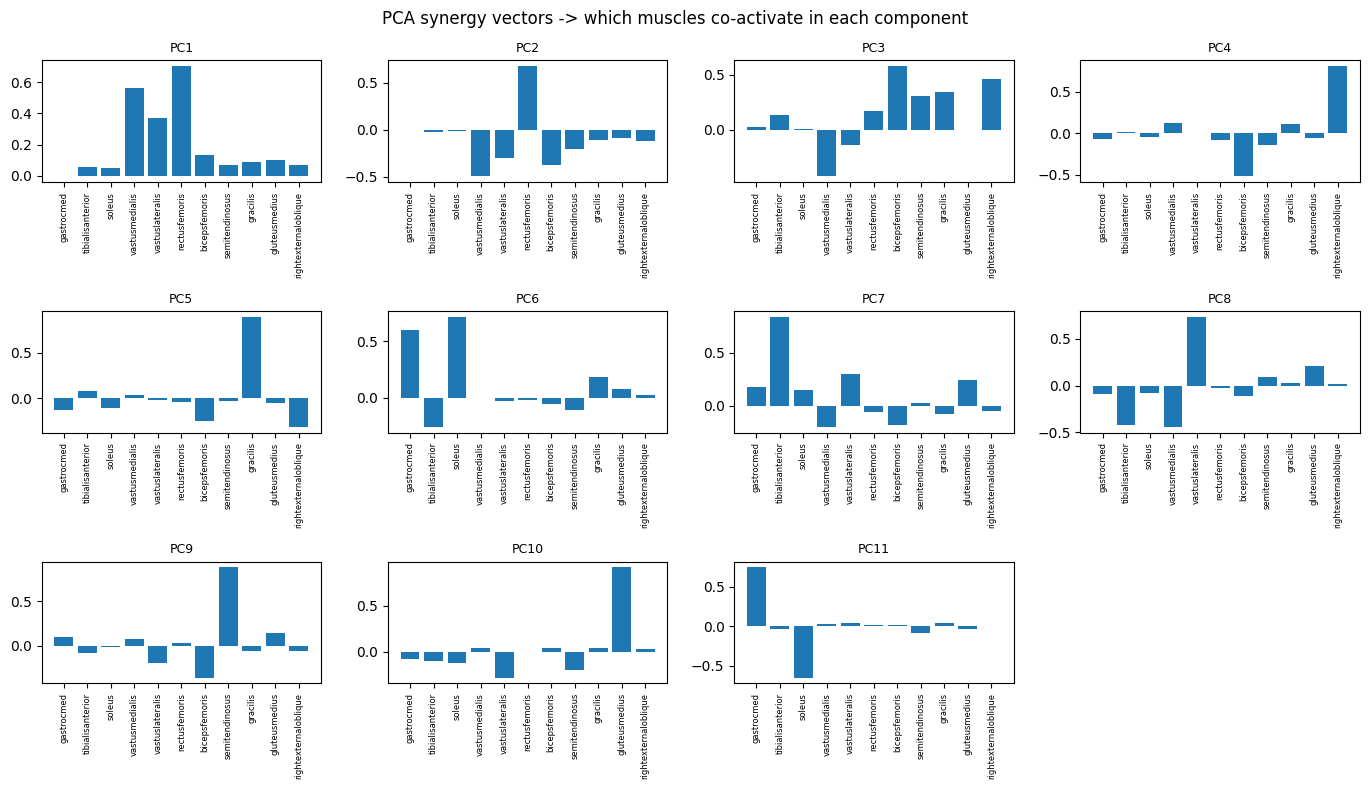

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for k in range(11):
    ax = axes.flat[k]
    ax.bar(range(11), pca.components_[k])
    ax.set_xticks(range(11))
    ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
    ax.set_title(f"PC{k+1}", fontsize=9)
axes.flat[-1].axis("off")
fig.suptitle("PCA synergy vectors -> which muscles co-activate in each component")
fig.tight_layout()
# plt.savefig("pca_synergy_weights.png")
plt.show()

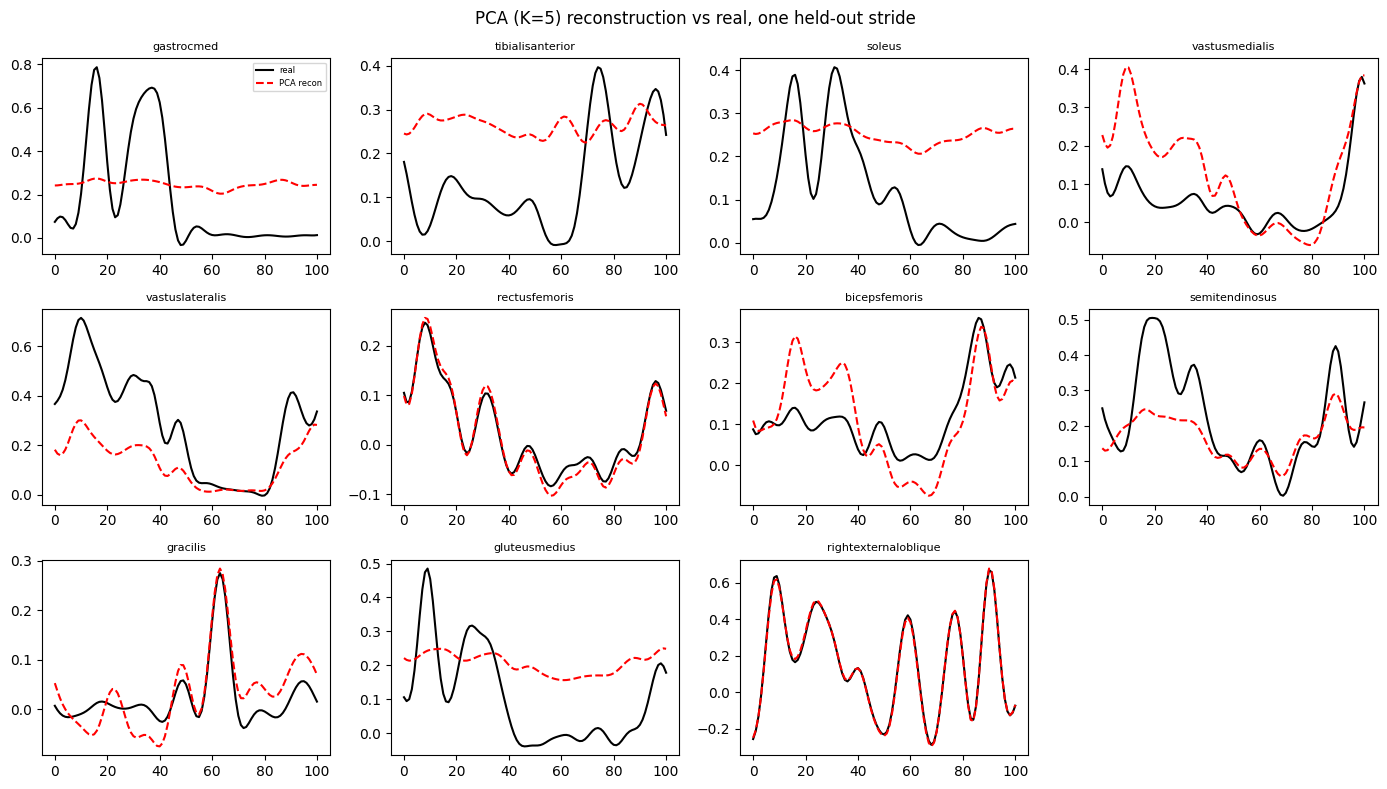

In [8]:
K_CHOSEN = 5   # 6 is better here
W = pca.components_[:K_CHOSEN]

stride_i = 0
real = strides_val[stride_i]
recon = ((real - pca.mean_) @ W.T) @ W + pca.mean_

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
    ax = axes.flat[c]
    ax.plot(real[:, c], color="black", label="real")
    ax.plot(recon[:, c], color="red", linestyle="--", label="PCA recon")
    ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6)
axes.flat[-1].axis("off")
fig.suptitle(f"PCA (K={K_CHOSEN}) reconstruction vs real, one held-out stride")
fig.tight_layout()
# plt.savefig("pca_waveform_recon.png")
plt.show()

/tmp/ipykernel_2119547/3359206076.py:23: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2119547/3359206076.py:23: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


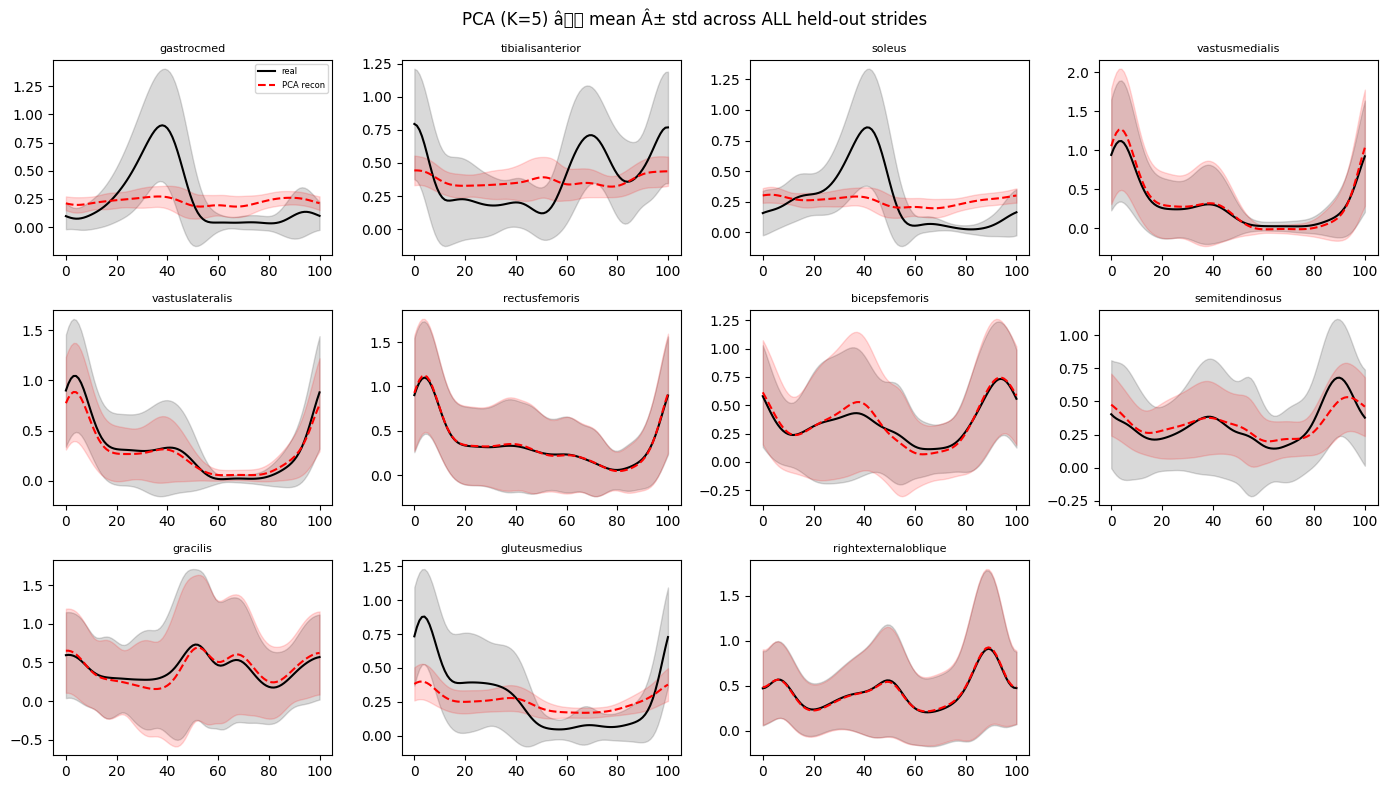

In [9]:
K_CHOSEN = 5   # 6 is better here
W = pca.components_[:K_CHOSEN]

val_flat = strides_val.reshape(-1, 11)
recon_flat = ((val_flat - pca.mean_) @ W.T) @ W + pca.mean_
recon_strides = recon_flat.reshape(strides_val.shape)   # (n_strides, 101, 11)

real_mean, real_std = strides_val.mean(axis=0), strides_val.std(axis=0)
recon_mean, recon_std = recon_strides.mean(axis=0), recon_strides.std(axis=0)

x = np.arange(101)
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
    ax = axes.flat[c]
    ax.plot(x, real_mean[:, c], color="black", label="real")
    ax.fill_between(x, real_mean[:, c]-real_std[:, c], real_mean[:, c]+real_std[:, c], color="black", alpha=0.15)
    ax.plot(x, recon_mean[:, c], color="red", linestyle="--", label="PCA recon")
    ax.fill_between(x, recon_mean[:, c]-recon_std[:, c], recon_mean[:, c]+recon_std[:, c], color="red", alpha=0.15)
    ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6)
axes.flat[-1].axis("off")
fig.suptitle(f"PCA (K={K_CHOSEN}) â mean Â± std across ALL held-out strides")
fig.tight_layout()
# plt.savefig("pca_waveform_recon_avg.png")
plt.show()

### NNMF

like biomech fidelity paper - they were able to achieve k=10 with 40 muscle space but its data that's highly curated and of 1 single person.

In [ ]:
from sklearn.decomposition import NMF

X_train_nn = np.clip(X_train, 0, None)   #NMF needs non-negative input
X_val_nn = np.clip(X_val, 0, None)

rows = []
nmf_models = {}
for k in range(1, 12):
    nmf = NMF(n_components=k, init="nndsvda", max_iter=500, random_state=42)
    nmf.fit(X_train_nn)
    nmf_models[k] = nmf
    X_train_hat = nmf.inverse_transform(nmf.transform(X_train_nn))
    X_val_hat = nmf.inverse_transform(nmf.transform(X_val_nn))
    rows.append([k, r2(X_train, X_train_hat), r2(X_val, X_val_hat)])
    print(f"k={k} done")

nmf_table = pd.DataFrame(rows, columns=["K", "train_R2", "held_out_R2"])
# nmf_table.to_csv("nmf_r2_table.csv", index=False)
nmf_table

/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


k=1 done
k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done
k=9 done


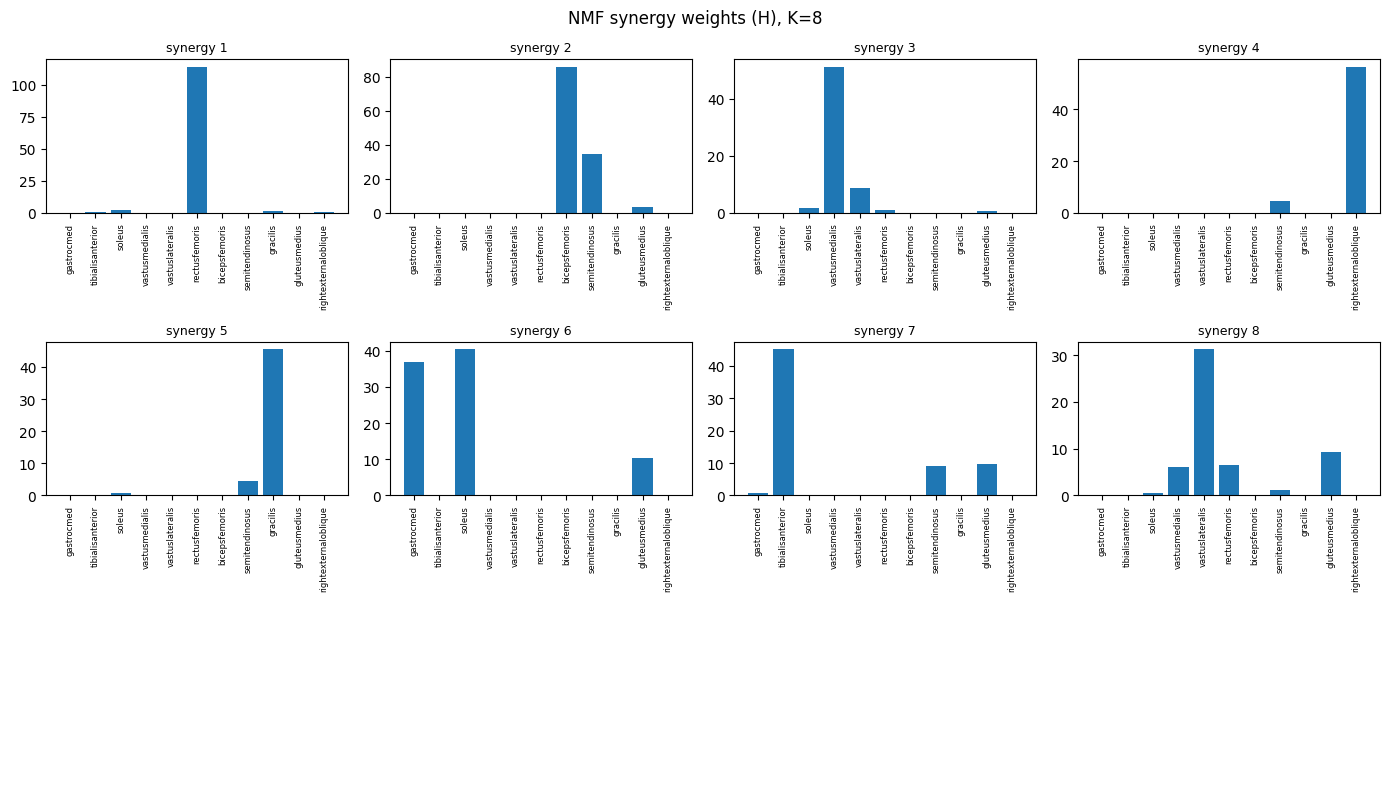

In [ ]:
K_CHOSEN = 8   # crosses 0.90 held_out_R2 in nmf_table
H = nmf_models[K_CHOSEN].components_   #(K, 11) -- their H, spatial synergy weights

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for k in range(K_CHOSEN):
    ax = axes.flat[k]
    ax.bar(range(11), H[k])
    ax.set_xticks(range(11))
    ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
    ax.set_title(f"synergy {k+1}", fontsize=9)
for ax in axes.flat[K_CHOSEN:]:
    ax.axis("off")
fig.suptitle(f"NMF synergy weights (H), K={K_CHOSEN}")
fig.tight_layout()
# plt.savefig("nmf_synergy_weights.png")
plt.show()

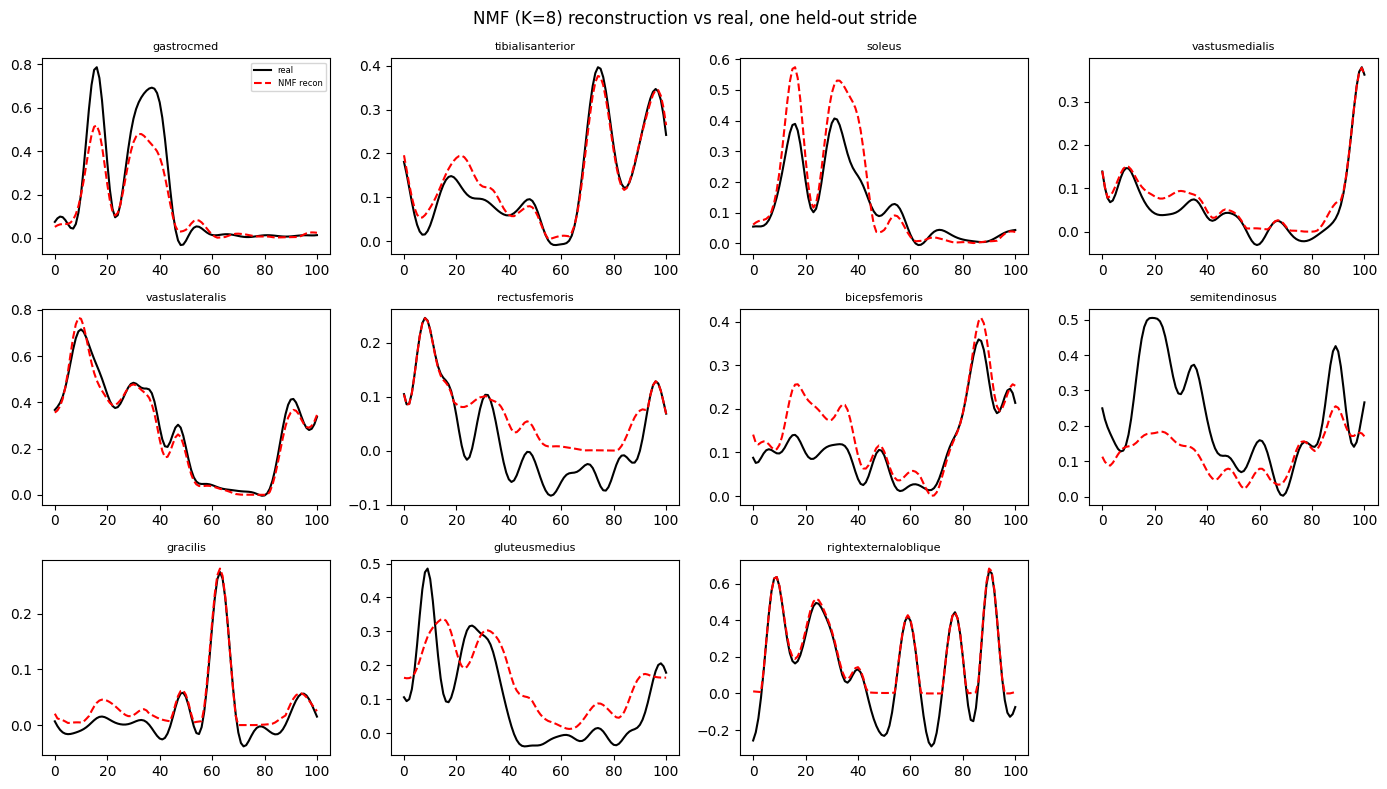

In [ ]:
nmf_k = nmf_models[K_CHOSEN]
stride_i = 0
real = strides_val[stride_i]
real_nn = np.clip(real, 0, None).astype(np.float32)
recon = nmf_k.inverse_transform(nmf_k.transform(real_nn))

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
    ax = axes.flat[c]
    ax.plot(real[:, c], color="black", label="real")
    ax.plot(recon[:, c], color="red", linestyle="--", label="NMF recon")
    ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6)
axes.flat[-1].axis("off")
fig.suptitle(f"NMF (K={K_CHOSEN}) reconstruction vs real, one held-out stride")
fig.tight_layout()
plt.savefig("nmf_waveform_recon.png")
plt.show()

/tmp/ipykernel_1841183/1811001419.py:23: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1841183/1811001419.py:23: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


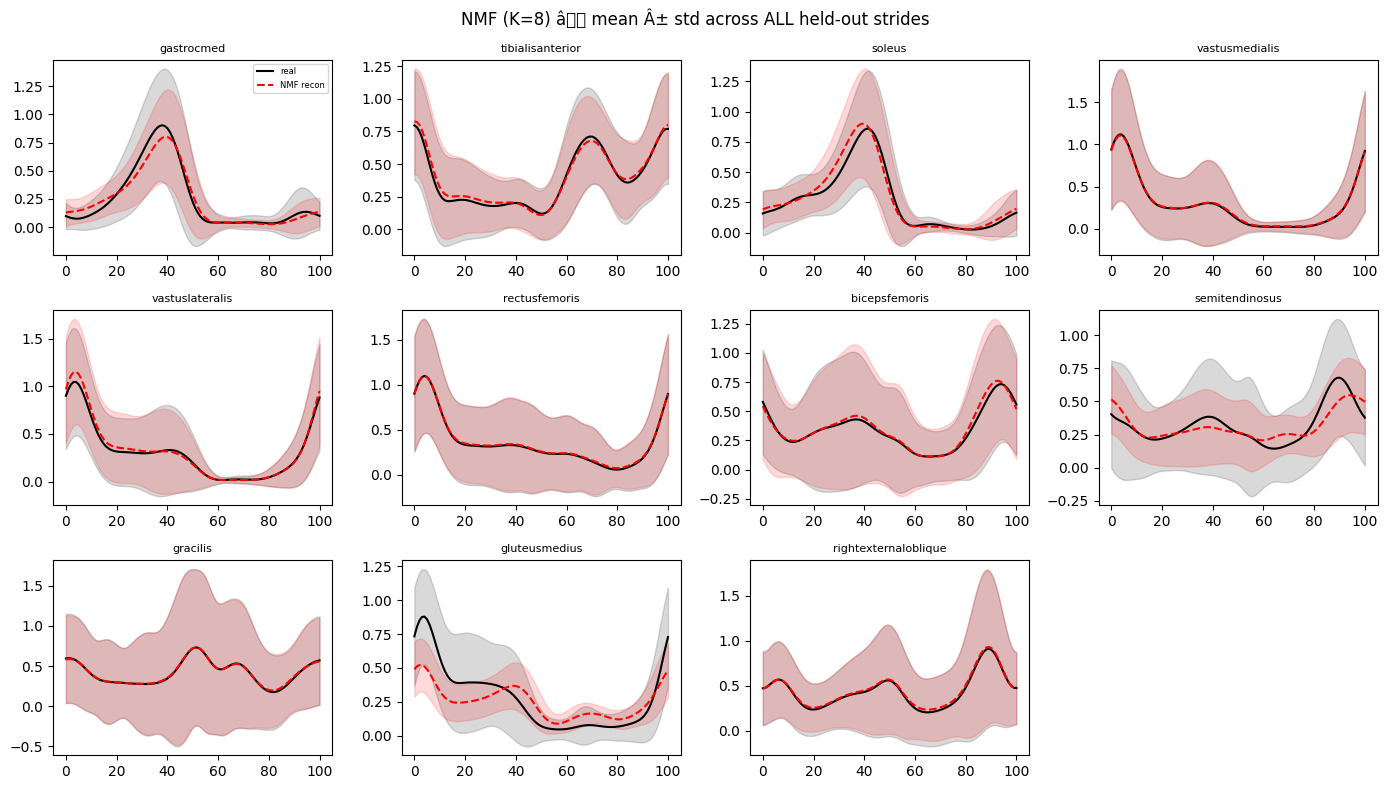

In [ ]:
K_CHOSEN = 8
nmf_k = nmf_models[K_CHOSEN]

val_flat_nn = np.clip(strides_val.reshape(-1, 11), 0, None).astype(np.float32)
recon_flat = nmf_k.inverse_transform(nmf_k.transform(val_flat_nn))
recon_strides = recon_flat.reshape(strides_val.shape)   # (n_strides, 101, 11)

real_mean, real_std = strides_val.mean(axis=0), strides_val.std(axis=0)
recon_mean, recon_std = recon_strides.mean(axis=0), recon_strides.std(axis=0)

x = np.arange(101)
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
    ax = axes.flat[c]
    ax.plot(x, real_mean[:, c], color="black", label="real")
    ax.fill_between(x, real_mean[:, c]-real_std[:, c], real_mean[:, c]+real_std[:, c], color="black", alpha=0.15)
    ax.plot(x, recon_mean[:, c], color="red", linestyle="--", label="NMF recon")
    ax.fill_between(x, recon_mean[:, c]-recon_std[:, c], recon_mean[:, c]+recon_std[:, c], color="red", alpha=0.15)
    ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6)
axes.flat[-1].axis("off")
fig.suptitle(f"NMF (K={K_CHOSEN}) â mean Â± std across ALL held-out strides")
fig.tight_layout()
# plt.savefig("nmf_waveform_recon_avg.png")
plt.show()

### ICA

In [ ]:
from sklearn.decomposition import FastICA

#fastica fits on subsamples to speed the iterative process and doesnt need all rows..
rng = np.random.default_rng(42)
sub_idx = rng.choice(len(X_train), size=min(100_000, len(X_train)), replace=False)
X_train_sub = X_train[sub_idx]

rows = []
ica_models = {}
for k in range(1, 12):
    ica = FastICA(n_components=k, random_state=42, max_iter=500)
    ica.fit(X_train_sub)
    ica_models[k] = ica
    X_train_hat = ica.inverse_transform(ica.transform(X_train))
    X_val_hat = ica.inverse_transform(ica.transform(X_val))
    rows.append([k, r2(X_train, X_train_hat), r2(X_val, X_val_hat)])
    print(f"k={k} done")

ica_table = pd.DataFrame(rows, columns=["K", "train_R2", "held_out_R2"])
# ica_table.to_csv("ica_r2_table.csv", index=False)
ica_table
sub_idx_all = sub_idx  # reused by the all-modes AE sweep, for a fair comparison


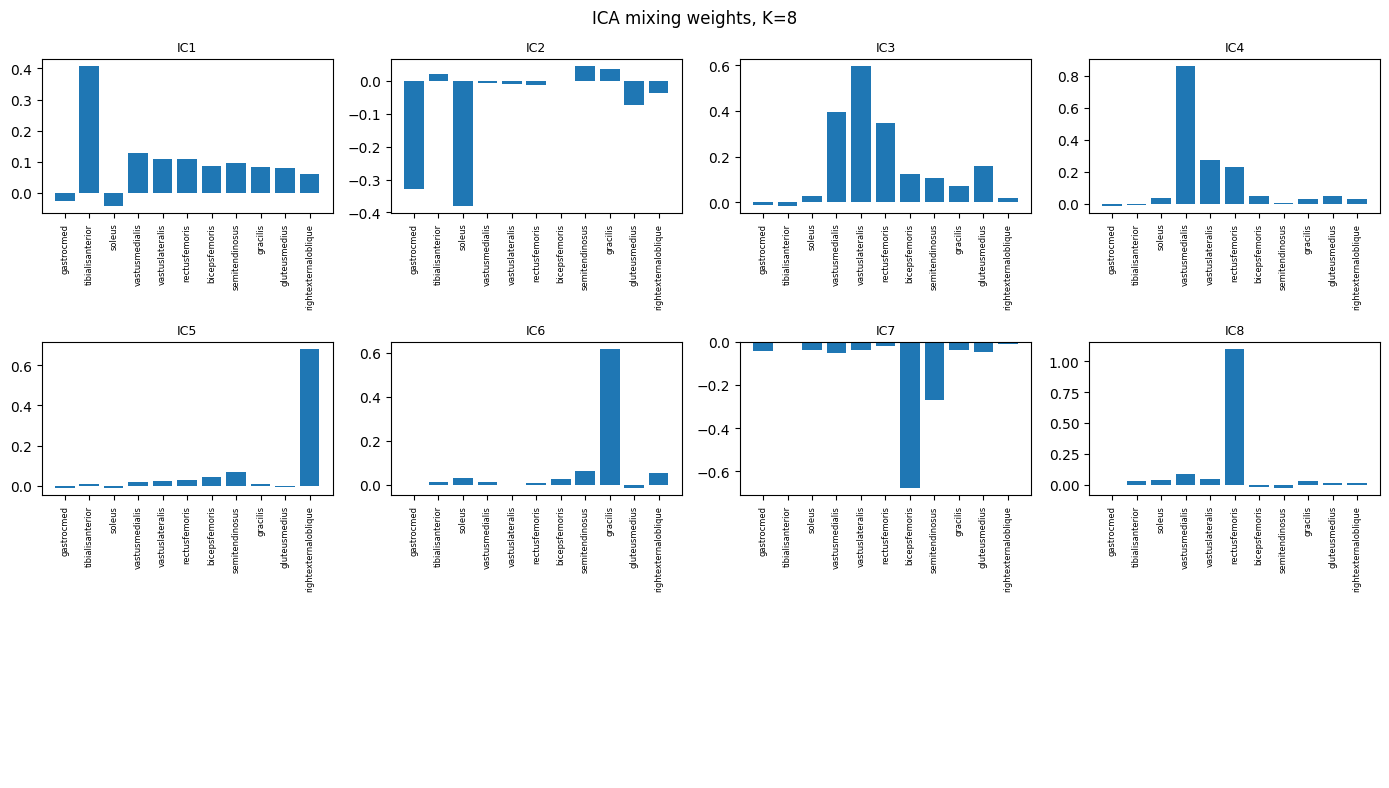

In [ ]:
K_CHOSEN = 8   # replace once you see ica_table
ica_k = ica_models[K_CHOSEN]
mixing = ica_k.mixing_.T   # (K, 11) -- row k = muscle weights for independent component k

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for k in range(K_CHOSEN):
    ax = axes.flat[k]
    ax.bar(range(11), mixing[k])
    ax.set_xticks(range(11))
    ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
    ax.set_title(f"IC{k+1}", fontsize=9)
for ax in axes.flat[K_CHOSEN:]:
    ax.axis("off")
fig.suptitle(f"ICA mixing weights, K={K_CHOSEN}")
fig.tight_layout()
# plt.savefig("ica_synergy_weights.png")
plt.show()

In [38]:
ica_k = ica_models[11]
val_flat = strides_val.reshape(-1, 11).astype(np.float32)
recon_flat = ica_k.inverse_transform(ica_k.transform(val_flat))
recon_strides = recon_flat.reshape(strides_val.shape)

real_mean, real_std = strides_val.mean(axis=0), strides_val.std(axis=0)
recon_mean, recon_std = recon_strides.mean(axis=0), recon_strides.std(axis=0)

x = np.arange(101)
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
    ax = axes.flat[c]
    ax.plot(x, real_mean[:, c], color="black", label="real")
    ax.fill_between(x, real_mean[:, c]-real_std[:, c], real_mean[:, c]+real_std[:, c], color="black", alpha=0.15)
    ax.plot(x, recon_mean[:, c], color="red", linestyle="--", label="ICA recon")
    ax.fill_between(x, recon_mean[:, c]-recon_std[:, c], recon_mean[:, c]+recon_std[:, c], color="red", alpha=0.15)
    ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6)
axes.flat[-1].axis("off")
fig.suptitle(f"ICA (K={K_CHOSEN}) â mean Â± std across ALL held-out strides")
fig.tight_layout()
# plt.savefig("ica_waveform_recon_avg.png")
plt.show()

NameError: name 'ica_models' is not defined

## Pool all subjects treadmill only

In [ ]:
##pool all subjects, treadmill only
train_tm_mask = meta_train["modes"] == "treadmill"
val_tm_mask = meta_val["modes"] == "treadmill"

X_train_tm = strides_train[train_tm_mask].reshape(-1, 11).astype(np.float32)
X_val_tm = strides_val[val_tm_mask].reshape(-1, 11).astype(np.float32)
print("train points:", len(X_train_tm), "val points:", len(X_val_tm))

X_train_tm_nn = np.clip(X_train_tm, 0, None)   # NMF needs non-negative input
X_val_tm_nn = np.clip(X_val_tm, 0, None)


### PCA

In [16]:
pca_tm = PCA(n_components=11)
pca_tm.fit(X_train_tm)

rows = []
for k in range(1, 12):
      W = pca_tm.components_[:k]
      X_train_hat = ((X_train_tm - pca_tm.mean_) @ W.T) @ W + pca_tm.mean_
      X_val_hat   = ((X_val_tm   - pca_tm.mean_) @ W.T) @ W + pca_tm.mean_
      rows.append([k, r2(X_train_tm, X_train_hat), r2(X_val_tm, X_val_hat)])
  
pca_tm_table = pd.DataFrame(rows, columns=["K", "train_R2", "held_out_R2"])
pca_tm_table

,K,train_R2,held_out_R2
0,1,0.340039,0.232068
1,2,0.523021,0.412110
2,3,0.630908,0.521892
3,4,0.725652,0.604207
4,5,0.811071,0.744056
5,6,0.890382,0.840989
6,7,0.931224,0.901011
7,8,0.958847,0.932321
8,9,0.980736,0.959173
9,10,0.990861,0.981910


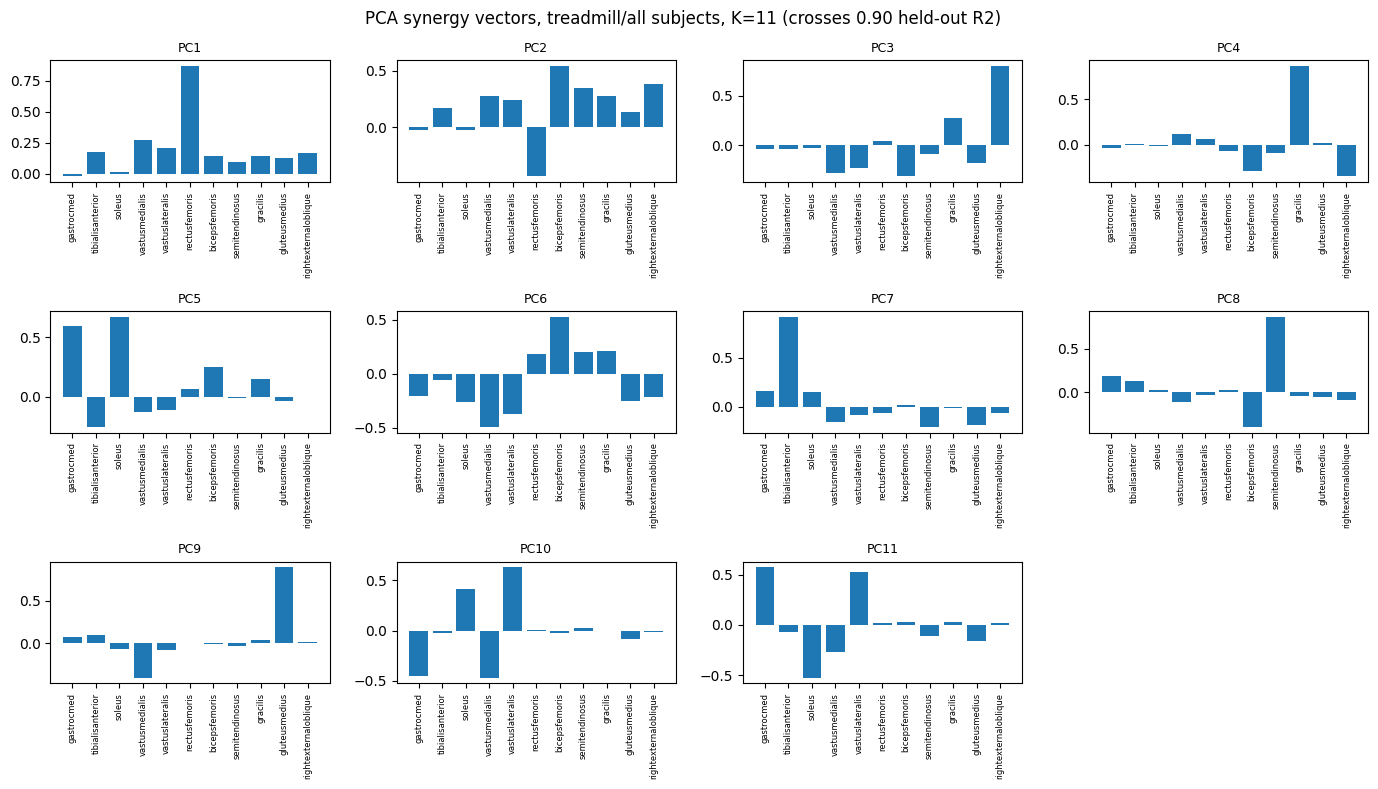

In [17]:
K_CHOSEN_PCA_TM = 11
W = pca_tm.components_[:K_CHOSEN_PCA_TM]
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for k in range(K_CHOSEN_PCA_TM):
      ax = axes.flat[k]
      ax.bar(range(11), pca_tm.components_[k])
      ax.set_xticks(range(11))
      ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
      ax.set_title(f"PC{k+1}", fontsize=9)
for ax in axes.flat[K_CHOSEN_PCA_TM:]:
      ax.axis("off")
      fig.suptitle(f"PCA synergy vectors, treadmill/all subjects, K={K_CHOSEN_PCA_TM} (crosses 0.90 held-out R2)")
      fig.tight_layout()
      plt.show()

### NNMF

In [34]:
def sweep_nmf(X_train, X_val, X_train_nn, X_val_nn, max_k=11):
      rows = []
      models = {}
      for k in range(1, max_k + 1):
          nmf = NMF(n_components=k, init="nndsvda", max_iter=500, random_state=42)
          nmf.fit(X_train_nn)                    # <-- this line was missing
          models[k] = nmf
          X_train_hat = nmf.inverse_transform(nmf.transform(X_train_nn))
          X_val_hat = nmf.inverse_transform(nmf.transform(X_val_nn))
          rows.append([k, r2(X_train, X_train_hat), r2(X_val, X_val_hat)])
      return pd.DataFrame(rows, columns=["K", "train_R2", "held_out_R2"]), models

nmf_tm_table, nmf_models_tm = sweep_nmf(X_train_tm, X_val_tm, X_train_tm_nn, X_val_tm_nn)
assert nmf_tm_table.shape == (11, 3), nmf_tm_table.shape
nmf_tm_table

/home/nadinebadie/anaconda3/envs/leaps/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


,K,train_R2,held_out_R2
0,1,0.248320,0.234653
1,2,0.467567,0.368634
2,3,0.574771,0.478847
3,4,0.672544,0.626744
4,5,0.764951,0.710479
5,6,0.849562,0.824719
6,7,0.895978,0.897418
7,8,0.925666,0.928521
8,9,0.949280,0.956937
9,10,0.958503,0.978244


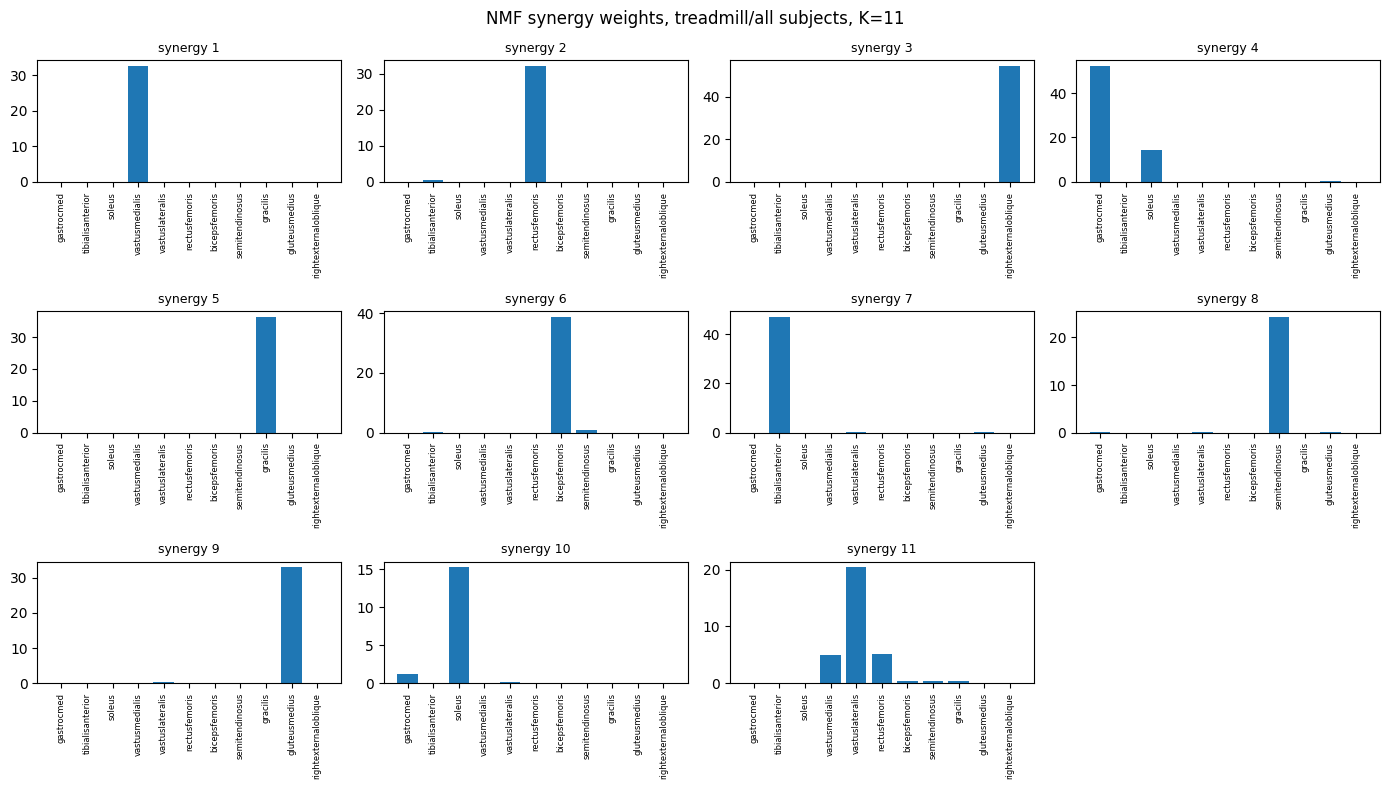

In [35]:
K_CHOSEN_NMF_TM = 11
H = nmf_models_tm[K_CHOSEN_NMF_TM].components_

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for k in range(K_CHOSEN_NMF_TM):
      ax = axes.flat[k]
      ax.bar(range(11), H[k])
      ax.set_xticks(range(11))
      ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
      ax.set_title(f"synergy {k+1}", fontsize=9)
for ax in axes.flat[K_CHOSEN_NMF_TM:]:
      ax.axis("off")
fig.suptitle(f"NMF synergy weights, treadmill/all subjects, K={K_CHOSEN_NMF_TM}")
fig.tight_layout()
plt.show()

### ICA

In [ ]:
from sklearn.decomposition import FastICA

rng = np.random.default_rng(42)
sub_idx = rng.choice(len(X_train_tm), size=min(100_000, len(X_train_tm)), replace=False)
X_train_tm_sub = X_train_tm[sub_idx]
  
def sweep_ica(X_train, X_val, X_train_sub, max_k=11):
      rows = []
      models = {}
      for k in range(1, max_k + 1):
          ica = FastICA(n_components=k, random_state=42, max_iter=500)
          ica.fit(X_train_sub)                   #fit the model
          
          models[k] = ica
          X_train_hat = ica.inverse_transform(ica.transform(X_train))
          X_val_hat = ica.inverse_transform(ica.transform(X_val))
          rows.append([k, r2(X_train, X_train_hat), r2(X_val, X_val_hat)])
      return pd.DataFrame(rows, columns=["K", "train_R2", "held_out_R2"]), models
  
ica_tm_table, ica_models_tm = sweep_ica(X_train_tm, X_val_tm, X_train_tm_sub)
assert ica_tm_table.shape == (11, 3), ica_tm_table.shape   #getting shapes in multuples of 11.. will debug later
ica_tm_table
sub_idx_tm = sub_idx  # reused by the treadmill AE sweep, for a fair comparison


In [37]:
# K_CHOSEN_ICA_TM = int(ica_tm_table.loc[ica_tm_table.held_out_R2 >= 0.90, "K"].min())
K_CHOSEN_ICA_TM = 11
mixing = ica_models_tm[K_CHOSEN_ICA_TM].mixing_.T

for k in range(K_CHOSEN_ICA_TM):
      ax = axes.flat[k]
      ax.bar(range(11), mixing[k])
      ax.set_xticks(range(11))
      ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
      ax.set_title(f"IC{k+1}", fontsize=9)
for ax in axes.flat[K_CHOSEN_ICA_TM:]:
      ax.axis("off")
fig.suptitle(f"ICA mixing weights, treadmill/all subjects, K={K_CHOSEN_ICA_TM}")
fig.tight_layout()
plt.show()

In [22]:
comparison_tm = pd.DataFrame({
      "K": pca_tm_table["K"],
      "PCA": pca_tm_table["held_out_R2"],
      "NMF": nmf_tm_table["held_out_R2"],
      "ICA": ica_tm_table["held_out_R2"],
  })

comparison_tm

,K,PCA,NMF,ICA
0,1.0,0.232068,0.232068,0.232068
1,2.0,0.412110,0.412110,0.412110
2,3.0,0.521892,0.521892,0.521892
3,4.0,0.604207,0.604207,0.604207
4,5.0,0.744056,0.744056,0.744056
5,6.0,0.840989,0.840989,0.840989
6,7.0,0.901011,0.901011,0.901011
7,8.0,0.932321,0.932321,0.932321
8,9.0,0.959173,0.959173,0.959173
9,10.0,0.981910,0.981910,0.981910


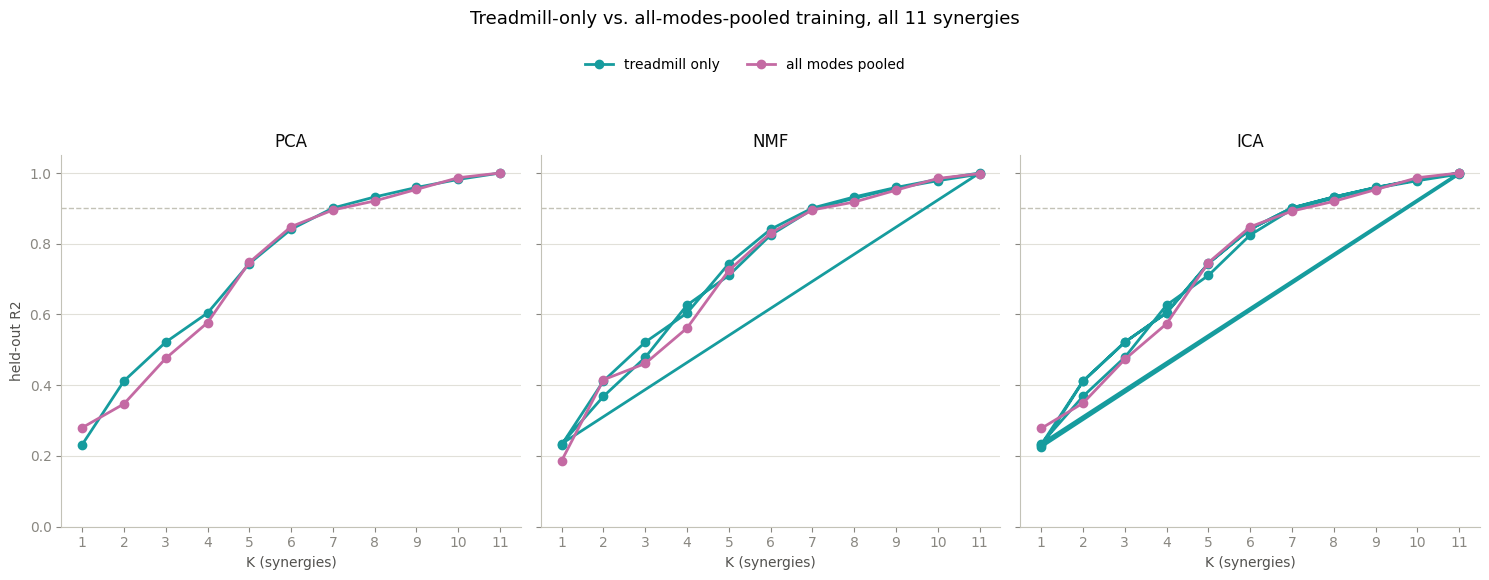

In [23]:
COLOR_TREADMILL = "#169c9e"   # blue
COLOR_ALL_MODES = "#c46aa3"   # aqua

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

panels = [
      ("PCA", pca_tm_table, pca_table),
      ("NMF", nmf_tm_table, nmf_table),
      ("ICA", ica_tm_table, ica_table),
  ]
  
for ax, (name, tm_table, all_table) in zip(axes, panels):
      ax.plot(tm_table["K"], tm_table["held_out_R2"], color=COLOR_TREADMILL,
              linewidth=2, marker="o", markersize=6, label="treadmill only")
      ax.plot(all_table["K"], all_table["held_out_R2"], color=COLOR_ALL_MODES,
              linewidth=2, marker="o", markersize=6, label="all modes pooled")
      ax.axhline(0.90, color="#c3c2b7", linestyle="--", linewidth=1, zorder=0)
      ax.set_title(name, fontsize=12, color="#0b0b0b")
      ax.set_xlabel("K (synergies)", color="#52514e")
      ax.set_xticks(range(1, 12))
      ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=-1)
      for spine in ["top", "right"]:
          ax.spines[spine].set_visible(False)
      for spine in ["left", "bottom"]:
          ax.spines[spine].set_color("#c3c2b7")
      ax.tick_params(colors="#898781")
  
axes[0].set_ylabel("held-out R2", color="#52514e")
axes[0].set_ylim(0, 1.05)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08),
            ncol=2, frameon=False, fontsize=10)
fig.suptitle("Treadmill-only vs. all-modes-pooled training, all 11 synergies", y=1.15, fontsize=13)
fig.tight_layout()
plt.show()

## Does mode matter? How many subject strides needed for training?

- For us, treadmill data suits the most because the paper's future direction suggests conditioning tgt velocity on the prior. We have different treadmill speeds and it doesn't involve turn transitions. 

1. Group baseline (top of notebook) — PCA/NMF/ICA fit on all 22 subjects, all modes pooled. Held-out R² crossed 0.90 around K=8. This was the reference point everything else got compared against.
 
2. Single-subject sanity check — fit on one subject (AB25), all modes, evaluated against that same subject's own held-out strides. Hit 0.90 R² by K≈3 — much lower than the group's K≈8. First hint that less data looks deceptively good if you only test it against itself.

3. Reference paper clarified their method actually trains an action-only autoencoder on a single gait cycle, with a tanh/[-1,1] convention suited to torque control. We corrected that for your project: SCONE muscle excitations are [0,1] (confirmed via depRL/deprl/env_wrappers/scone_wrapper.py), so any AE here should use sigmoid, not tanh.

4. Single-gait-cycle test — the real stress test: fit PCA on one stride from one subject, evaluate against (a) that subject's other strides and (b) every other subject. Result: 0.92 same-subject vs 0.76 other-subjects at K=8. This was the first hard evidence that minimal data has a real generalization cost —not just an in-sample illusion.

5. Subject-count scaling curve (single draw) — swept N=1,2,4,8,18 training subjects (treadmill only, chosen for task-relevance) against a fixed held-out set of 4 subjects. Looked noisy/non-monotonic — couldn't yet tell signal from randomness.

6. Bootstrapped version (5 repeats per N) — fixed the noise problem. Result: at K≈7-9, N=1 ≈ N=2 ≈ N=18, all within one std of each other. At low K (1-2), N=1 has much higher variance (picking one unlucky subject hurts), but that variance shrinks fast with N=2+. Conclusion: pool all subjects — costs nothing, removes the low-K risk.

7. Cross-mode check — trained on treadmill (all subjects pooled), tested reconstruction against held-out treadmill/levelground/ramp/stair. Surprisingly generalized well to all four (levelground even reconstructed better than treadmill's own held-out at high K).

8. Dilution check — the real test of whether mixing modes helps or hurts: trained on all modes pooled, broke down held-out R² per mode, and compared directly to the treadmill-only model. Treadmill-only won on every mode, including the ones it never saw (e.g. treadmill: 0.932 vs 0.908; levelground: 0.963 vs 0.941). Confirmed pooling heterogeneous modes produces a worse basis for everyone — real dilution, not assumption.

9. Reverse-direction check — trained separately on levelground-only, ramp-only, stair-only to see if treadmill was uniquely good or just "a" good single mode.
  
Result: levelground-only ties treadmill-only almost exactly; ramp-only and stair-only both generalize noticeably worse. So the real distinction is flat-ground walking (treadmill/levelground) vs. incline/stepping (ramp/stair) — not "treadmill is special."

CONCLUSION: Pool all subjects (step 6 showed no downside), use treadmill only (step 8 showed pooling modes hurts everyone; step 9 showed levelground would've worked equally well, but treadmill's constant, discretely-labeled speeds match H0918's constant-velocity walk task more directly).

In [24]:
#how much data do we actually need

val_tm_mask = meta_val["modes"] == "treadmill"
X_val_tm = strides_val[val_tm_mask].reshape(-1, 11).astype(np.float32)
print("held-out subjects:", sorted(set(meta_val["subjects"]))) #the same ones from before (4)
print("held-out treadmill points:", len(X_val_tm))


train_tm_mask = meta_train["modes"] == "treadmill"
train_subjects = sorted(set(meta_train["subjects"][train_tm_mask]))
print("available training subjects:", len(train_subjects))

held-out subjects: ['AB16', 'AB23', 'AB24', 'AB30']
held-out treadmill points: 328957
available training subjects: 18


From the scaling table below, we can see that adding more people isn't adding much benefit. Actually the increase isnt even monotonic.. it depends on the person we are drawing this from.. I think treadmill trial from 1 person alone generalizes pretty well on average but it looks like who we pick matters. BETTER TO POOL ALL SUBJECT STRIDES


In [25]:
from sklearn.decomposition import PCA

rng_scale = np.random.default_rng(7)
shuffled_subjects = rng_scale.permutation(train_subjects).tolist()
N_VALUES = [1, 2, 4, 8, len(shuffled_subjects)]

#scaling sweep- how many subjects do we need to get good held-out R2? 
rows = []
for n in N_VALUES:
      subj_subset = shuffled_subjects[:n]
      subset_mask = train_tm_mask & np.isin(meta_train["subjects"], subj_subset)
      X_n = strides_train[subset_mask].reshape(-1, 11).astype(np.float32)

      pca_n = PCA(n_components=11)
      pca_n.fit(X_n)
      
      for k in range(1, 12):
          W = pca_n.components_[:k]
          X_val_hat = ((X_val_tm - pca_n.mean_) @ W.T) @ W + pca_n.mean_
          rows.append([n, len(X_n), k, r2(X_val_tm, X_val_hat)])

scaling_table = pd.DataFrame(rows, columns=["N_subjects", "n_transitions", "K", "held_out_R2"])
scaling_table

,N_subjects,n_transitions,K,held_out_R2
0,1,81002,1,0.176716
1,1,81002,2,0.323139
2,1,81002,3,0.421872
3,1,81002,4,0.579700
4,1,81002,5,0.678496
5,1,81002,6,0.754506
6,1,81002,7,0.875673
7,1,81002,8,0.916028
8,1,81002,9,0.966015
9,1,81002,10,0.982433


In [26]:
#does a treadmill only basis explain levelground transitions

val_lg_mask = meta_val["modes"] == "levelground"
X_val_lg = strides_val[val_lg_mask].reshape(-1, 11).astype(np.float32)

pca_all = PCA(n_components=11)
pca_all.fit(strides_train[train_tm_mask].reshape(-1, 11).astype(np.float32))

rows = []
for k in range(1, 12):
      W = pca_all.components_[:k]
      tm_hat = ((X_val_tm - pca_all.mean_) @ W.T) @ W + pca_all.mean_
      lg_hat = ((X_val_lg - pca_all.mean_) @ W.T) @ W + pca_all.mean_
      rows.append([k, r2(X_val_tm, tm_hat), r2(X_val_lg, lg_hat)])
      rows.append([k, r2(X_val_tm, tm_hat), r2(X_val_lg, lg_hat)])

cross_mode_table = pd.DataFrame(rows, columns=["K", "held_out_treadmill_R2", "held_out_levelground_R2"])
cross_mode_table

,K,held_out_treadmill_R2,held_out_levelground_R2
0,1,0.232068,0.094234
1,1,0.232068,0.094234
2,2,0.412110,0.249453
3,2,0.412110,0.249453
4,3,0.521892,0.406549
5,3,0.521892,0.406549
6,4,0.604207,0.734400
7,4,0.604207,0.734400
8,5,0.744056,0.825528
9,5,0.744056,0.825528


In [27]:
pca_treadmill_only = PCA(n_components=11)
pca_treadmill_only.fit(strides_train[train_tm_mask].reshape(-1, 11).astype(np.float32))

rows = []
for mode in ["treadmill", "levelground", "ramp", "stair"]:
      mode_mask = meta_val["modes"] == mode
      X_val_mode = strides_val[mode_mask].reshape(-1, 11).astype(np.float32)
      for k in range(1, 12):
          W = pca_treadmill_only.components_[:k]
          X_hat = ((X_val_mode - pca_treadmill_only.mean_) @ W.T) @ W + pca_treadmill_only.mean_
          rows.append([mode, k, r2(X_val_mode, X_hat)])

cross_mode_table = pd.DataFrame(rows, columns=["mode", "K", "held_out_R2"])
cross_mode_table.pivot(index="K", columns="mode", values="held_out_R2")

mode,levelground,ramp,stair,treadmill
K,,,,
1,0.094234,0.225579,0.247251,0.232068
2,0.249453,0.364882,0.358055,0.412110
3,0.406549,0.486068,0.442072,0.521892
4,0.734400,0.643014,0.590848,0.604207
5,0.825528,0.750195,0.659760,0.744056
6,0.906984,0.844499,0.815552,0.840989
7,0.937920,0.893908,0.891385,0.901011
8,0.963040,0.937290,0.928012,0.932321
9,0.979741,0.973725,0.971855,0.959173


In [28]:
#does pooling all modes together hurt treadmill reconstruction
pca_all_modes = PCA(n_components=11)
pca_all_modes.fit(X_train)   # the original all-subjects, all-modes training pool 

rows = []
for mode in ["treadmill", "levelground", "ramp", "stair"]:
  pca_all_modes.fit(X_train)   # the original all-subjects, all-modes training pool from the top of the notebook

rows = []
for mode in ["treadmill", "levelground", "ramp", "stair"]:
      mode_mask = meta_val["modes"] == mode
      X_val_mode = strides_val[mode_mask].reshape(-1, 11).astype(np.float32)
      for k in range(1, 12):
          W = pca_all_modes.components_[:k]
          X_hat = ((X_val_mode - pca_all_modes.mean_) @ W.T) @ W + pca_all_modes.mean_
          rows.append([mode, k, r2(X_val_mode, X_hat)])

all_modes_table = pd.DataFrame(rows, columns=["mode", "K", "held_out_R2"])
all_modes_table.pivot(index="K", columns="mode", values="held_out_R2")

mode,levelground,ramp,stair,treadmill
K,,,,
1,0.102835,0.311501,0.373172,0.243879
2,0.147232,0.377099,0.457764,0.327007
3,0.317183,0.484801,0.569875,0.471762
4,0.458090,0.583943,0.616555,0.587349
5,0.799708,0.747584,0.773549,0.667781
6,0.888402,0.846825,0.843805,0.807694
7,0.923432,0.892503,0.885236,0.873211
8,0.940833,0.914082,0.916780,0.908326
9,0.966509,0.955481,0.947687,0.941074


## Autoencoder Vanilla Implementation

In [11]:
#get muscle profile per mode
#we would like to scale the activations to [0,1] based on the range that 98% of the data actually falls in.. anything more is a 1 or 0.
#computed per mode
rows = []
for mode in ["treadmill", "levelground", "ramp", "stair"]:
      mask = meta_train["modes"] == mode
      X = strides_train[mask].reshape(-1, 11)
      for i, ch in enumerate(EMG_CHANNELS):
          col = X[:, i]
          rows.append([mode, ch, col.min(), col.max(), col.mean(), col.std(),
                       np.percentile(col, 1), np.percentile(col, 99)])
                       
profile = pd.DataFrame(rows, columns=["mode", "muscle", "min", "max", "mean", "std", "p01", "p99"])
profile.round(2)

,mode,muscle,min,max,mean,std,p01,p99
0,treadmill,gastrocmed,-0.09,3.69,0.24,0.35,-0.02,1.42
1,treadmill,tibialisanterior,-0.47,5.08,0.36,0.41,-0.10,1.70
2,treadmill,soleus,-0.47,4.77,0.27,0.38,-0.27,1.70
3,treadmill,vastusmedialis,-1.13,8.28,0.22,0.47,-0.77,2.23
4,treadmill,vastuslateralis,-0.81,7.25,0.20,0.38,-0.17,1.73
5,treadmill,rectusfemoris,-3.29,33.16,0.32,0.93,-1.81,3.31
6,treadmill,bicepsfemoris,-1.53,23.02,0.30,0.57,-0.07,2.34
7,treadmill,semitendinosus,-0.38,6.06,0.28,0.39,-0.04,1.66
8,treadmill,gracilis,-2.53,25.57,0.31,0.55,-0.10,2.17
9,treadmill,gluteusmedius,-0.24,9.44,0.27,0.32,-0.07,1.34


Let's get the percentile bounds per mode

In [12]:
modes = ["treadmill", "levelground", "ramp", "stair"]
mode_bounds = {}

for mode in modes:
      mask = meta_train["modes"] == mode
      X_mode = strides_train[mask].reshape(-1, 11)
      p01 = np.percentile(X_mode, 1, axis=0)
      p99 = np.percentile(X_mode, 99, axis=0)
      mode_bounds[mode] = (p01, p99)
      print(mode, "p01:", p01.round(2))
      print(mode, "p99:", p99.round(2))

treadmill p01: [-0.02 -0.1  -0.27 -0.77 -0.17 -1.81 -0.07 -0.04 -0.1  -0.07 -0.55]
treadmill p99: [1.42 1.7  1.7  2.23 1.73 3.31 2.34 1.66 2.17 1.34 2.41]
levelground p01: [-0.02 -0.15 -0.34 -0.81 -0.21 -1.95 -0.09 -0.03 -0.08 -0.08 -0.48]
levelground p99: [1.49 1.65 1.66 1.54 1.49 2.22 3.03 1.89 2.84 1.22 3.1 ]
ramp p01: [-0.05 -0.11 -0.55 -0.69 -0.14 -1.58 -0.08 -0.04 -1.25 -0.09 -0.52]
ramp p99: [1.94 1.84 2.21 6.21 4.01 4.41 4.25 2.37 3.07 1.54 3.75]
stair p01: [-0.05 -0.15 -0.52 -0.68 -0.2  -1.55 -0.09 -0.06 -1.41 -0.1  -0.55]
stair p99: [1.85 1.86 1.78 7.45 4.75 8.17 3.3  2.21 2.58 1.65 2.  ]


In [13]:
def to_unit(x, mode):
    p01, p99 = mode_bounds[mode]
    return np.clip((x - p01) / (p99 - p01 + 1e-8), 0, 1).astype(np.float32)

def from_unit(x, mode):
    p01, p99 = mode_bounds[mode]
    return (x * (p99 - p01 + 1e-8) + p01).astype(np.float32)


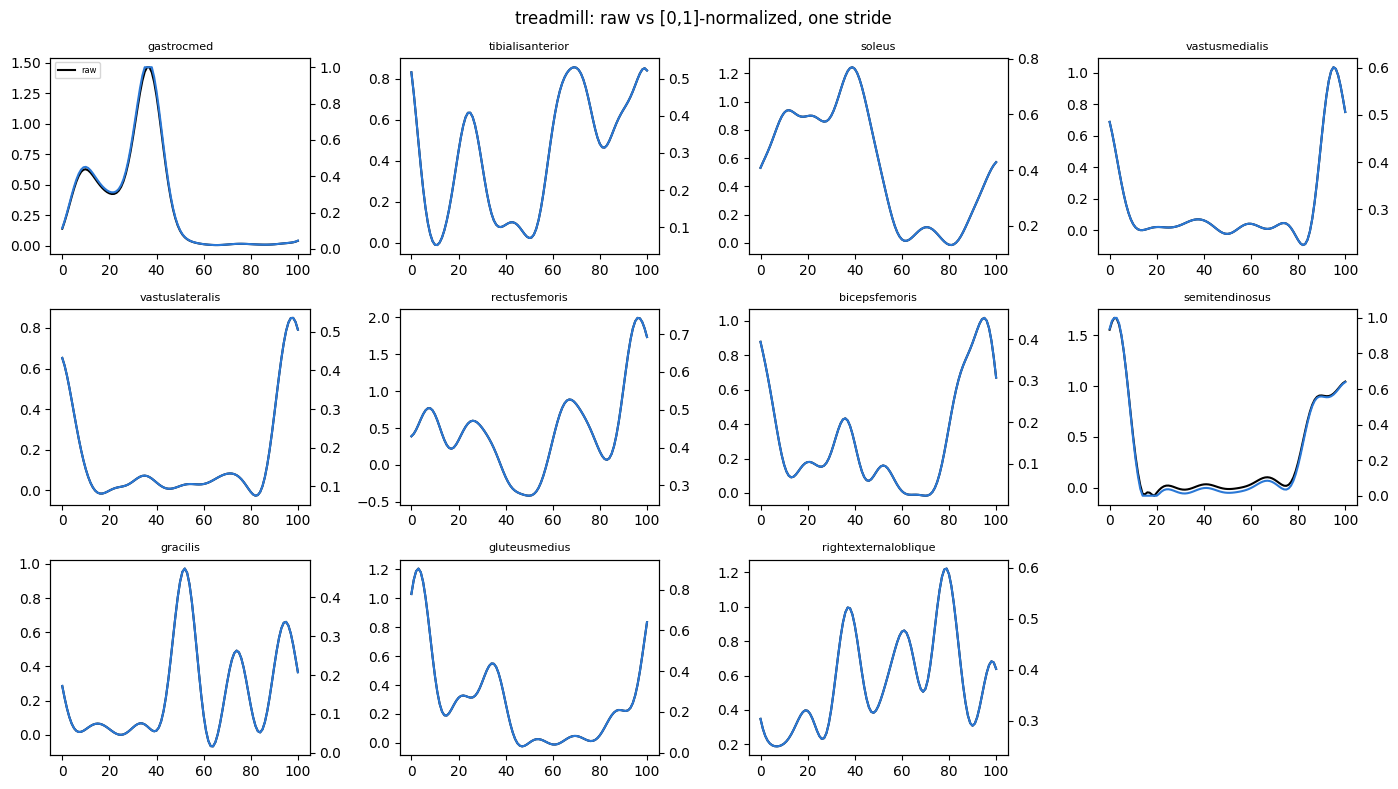

In [14]:
mode = "treadmill"
mask = meta_train["modes"] == mode
strides_mode = strides_train[mask]
  
stride_i = 34  #get std
raw_stride = strides_mode[stride_i]
norm_stride = to_unit(raw_stride, mode)
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
      ax = axes.flat[c]
      ax.plot(raw_stride[:, c], color="black", label="raw")
      ax2 = ax.twinx()
      ax2.plot(norm_stride[:, c], color="#2a78d6", label="[0,1] normalized")
      ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6, loc="upper left")
axes.flat[-1].axis("off")
fig.suptitle(f"{mode}: raw vs [0,1]-normalized, one stride")
fig.tight_layout()
plt.show()

### Just MSE (my old implementation)

In [21]:
# print(torch.get_num_threads()) 
torch.set_num_threads(1)

### MSE + Lnorm penalty (ref paper)

In [28]:
p01_all = np.percentile(X_train, 1, axis=0)
p99_all = np.percentile(X_train, 99, axis=0)

def to_unit_all(x):
    return np.clip((x - p01_all) / (p99_all - p01_all + 1e-8), 0, 1).astype(np.float32)

def from_unit_all(x):
    return (x * (p99_all - p01_all + 1e-8) + p01_all).astype(np.float32)

X_train_u = to_unit_all(X_train)
X_val_u = to_unit_all(X_val)

rng = np.random.default_rng(42)
sub_idx_all = rng.choice(len(X_train), size=min(100_000, len(X_train)), replace=False)
X_train_u_sub = X_train_u[sub_idx_all]

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# class LatentActionAE(nn.Module):
class LatentActionAESmall(nn.Module):
    """1 hidden layer, size 2*dim_latent, matching the paper's stated architecture - tanh hidden, sigmoid output """
    def __init__(self, dim_a, dim_latent):
        super().__init__()
        h = 2 * dim_latent
        self.encoder = nn.Sequential(nn.Linear(dim_a, h), nn.Tanh(), nn.Linear(h, dim_latent), nn.Sigmoid())
        self.decoder = nn.Sequential(nn.Linear(dim_latent, h), nn.Tanh(), nn.Linear(h, dim_a), nn.Sigmoid())
    def forward(self, a):
        a_l = self.encoder(a)
        return self.decoder(a_l), a_l

def train_ae_small(X_train_u_sub, dim_latent, epochs=50, batch_size=64, lr=1e-3, seed=0, penalty_weight=1.0):
    torch.manual_seed(seed)
    model = LatentActionAESmall(dim_a=11, dim_latent=dim_latent)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(torch.from_numpy(X_train_u_sub)), batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        for (batch,) in loader:
            a_hat, a_l = model(batch)
            loss = ((batch - a_hat) ** 2).sum(dim=-1).mean() + penalty_weight * latent_norm_penalty(a_l)
            opt.zero_grad(); loss.backward(); opt.step()
    return model


def latent_norm_penalty(a_l, threshold=0.8, scale=1.2):
    # ref paper: Lnorm(a_l) = 0 if ||a_l||_inf < threshold, else exp((||a_l||_inf/scale)**10) - 1,
    edge_dist = torch.minimum(a_l, 1.0 - a_l)   #0 at either edge, 0.5 at center
    near = 1.0 - 2.0 * edge_dist           #0 at center, 1 at either edge
    worst = near.max(dim=-1).values
    penalty = torch.where(worst < threshold, torch.zeros_like(worst), torch.exp((worst / scale) ** 10) - 1.0)
    return penalty.mean()


In [32]:
# pure MSE baseline
rows_mse = []
for k in range(1, 12):
    model = train_ae_small(X_train_u_sub, dim_latent=k, epochs=50, batch_size=64, penalty_weight=0.0)
    model.eval()
    with torch.no_grad():
        val_hat_u, _ = model(torch.from_numpy(X_val_u))
    val_hat = from_unit_all(val_hat_u.numpy())
    rows_mse.append([k, r2(X_val, val_hat)])
    print(f"[MSE] K={k} held_out_R2={rows_mse[-1][1]:.3f}")
ae_small_mse_table = pd.DataFrame(rows_mse, columns=["K", "held_out_R2"])
ae_small_mse_table

[MSE] K=1 held_out_R2=0.272
[MSE] K=2 held_out_R2=0.455
[MSE] K=3 held_out_R2=0.590
[MSE] K=4 held_out_R2=0.693
[MSE] K=5 held_out_R2=0.769
[MSE] K=6 held_out_R2=0.800
[MSE] K=7 held_out_R2=0.852
[MSE] K=8 held_out_R2=0.870
[MSE] K=9 held_out_R2=0.884
[MSE] K=10 held_out_R2=0.901
[MSE] K=11 held_out_R2=0.912


,K,held_out_R2
0,1,0.272102
1,2,0.455018
2,3,0.590221
3,4,0.693049
4,5,0.768678
5,6,0.800255
6,7,0.852476
7,8,0.869893
8,9,0.884241
9,10,0.901177


In [33]:
# MSE + Lnorm baseline (ref paper)
rows_ln = []
for k in range(1, 12):
    model = train_ae_small(X_train_u_sub, dim_latent=k, epochs=50, batch_size=64, penalty_weight=1.0)
    model.eval()
    with torch.no_grad():
        val_hat_u, _ = model(torch.from_numpy(X_val_u))
    val_hat = from_unit_all(val_hat_u.numpy())
    rows_ln.append([k, r2(X_val, val_hat)])
    print(f"[MSE+Lnorm] K={k} held_out_R2={rows_ln[-1][1]:.3f}")
ae_small_ln_table = pd.DataFrame(rows_ln, columns=["K", "held_out_R2"])

[MSE+Lnorm] K=1 held_out_R2=0.277
[MSE+Lnorm] K=2 held_out_R2=0.454
[MSE+Lnorm] K=3 held_out_R2=0.547
[MSE+Lnorm] K=4 held_out_R2=0.710
[MSE+Lnorm] K=5 held_out_R2=0.749
[MSE+Lnorm] K=6 held_out_R2=0.817
[MSE+Lnorm] K=7 held_out_R2=0.853
[MSE+Lnorm] K=8 held_out_R2=0.873
[MSE+Lnorm] K=9 held_out_R2=0.884
[MSE+Lnorm] K=10 held_out_R2=0.903
[MSE+Lnorm] K=11 held_out_R2=0.912


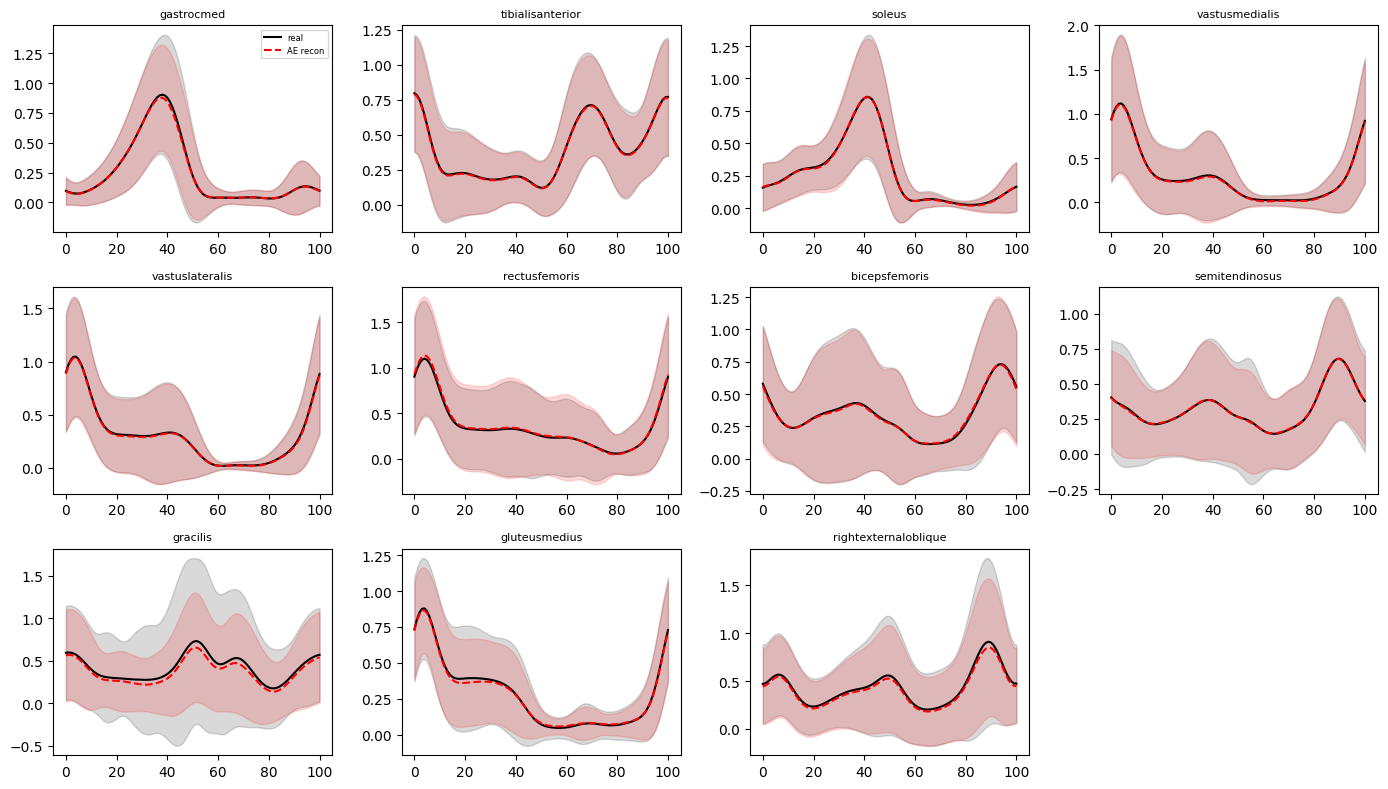

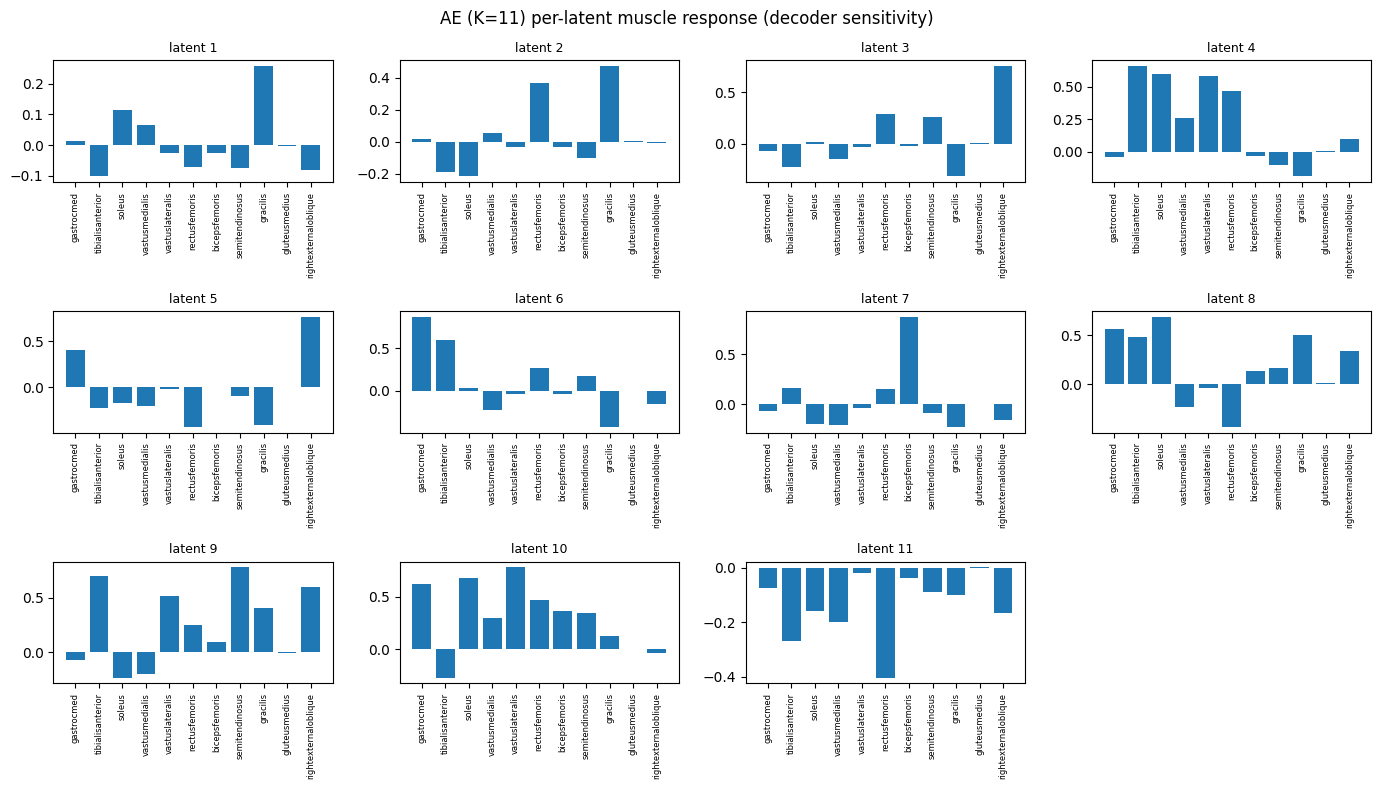

In [35]:
K_PLOT = 11
model = train_ae_small(X_train_u_sub, dim_latent=K_PLOT, epochs=50, batch_size=64, penalty_weight=0.0)
model.eval()

val_flat = strides_val.reshape(-1, 11).astype(np.float32)
val_flat_u = to_unit_all(val_flat)
with torch.no_grad():
    recon_flat_u, _ = model(torch.from_numpy(val_flat_u))
recon_flat = from_unit_all(recon_flat_u.numpy())
recon_strides = recon_flat.reshape(strides_val.shape)  # (n_strides, 101, 11)

real_mean, real_std = strides_val.mean(axis=0), strides_val.std(axis=0)
recon_mean, recon_std = recon_strides.mean(axis=0), recon_strides.std(axis=0)

x = np.arange(101)
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
    ax = axes.flat[c]
    ax.plot(x, real_mean[:, c], color="black", label="real")
    ax.fill_between(x, real_mean[:, c]-real_std[:, c], real_mean[:, c]+real_std[:, c], color="black", alpha=0.15)
    ax.plot(x, recon_mean[:, c], color="red", linestyle="--", label="AE recon")
    ax.fill_between(x, recon_mean[:, c]-recon_std[:, c], recon_mean[:, c]+recon_std[:, c], color="red", alpha=0.15)
    ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6)
axes.flat[-1].axis("off")
fig.tight_layout()
plt.show()

# muscle weights -- needs 11 slots now, not 6
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
base = torch.full((1, K_PLOT), 0.5)
with torch.no_grad():
    out0 = model.decoder(base).numpy()[0]
    for k in range(K_PLOT):
        z = base.clone(); z[0, k] = 1.0
        out = model.decoder(z).numpy()[0]
        ax = axes.flat[k]
        ax.bar(range(11), out - out0)
        ax.set_xticks(range(11)); ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=6)
        ax.set_title(f"latent {k+1}", fontsize=9)
for ax in axes.flat[K_PLOT:]:
    ax.axis("off")
fig.suptitle(f"AE (K={K_PLOT}) per-latent muscle response (decoder sensitivity)")
fig.tight_layout()
plt.show()

In [36]:
print("R2 here:", r2(val_flat, recon_flat))

print("real std per channel:  ", val_flat.std(axis=0).round(3))
print("recon std per channel: ", recon_flat.std(axis=0).round(3))

R2 here: 0.9122496396303177
real std per channel:   [0.385 0.379 0.344 0.502 0.445 0.525 0.458 0.388 0.686 0.351 0.534]
recon std per channel:  [0.366 0.369 0.345 0.499 0.441 0.55  0.452 0.361 0.492 0.325 0.493]


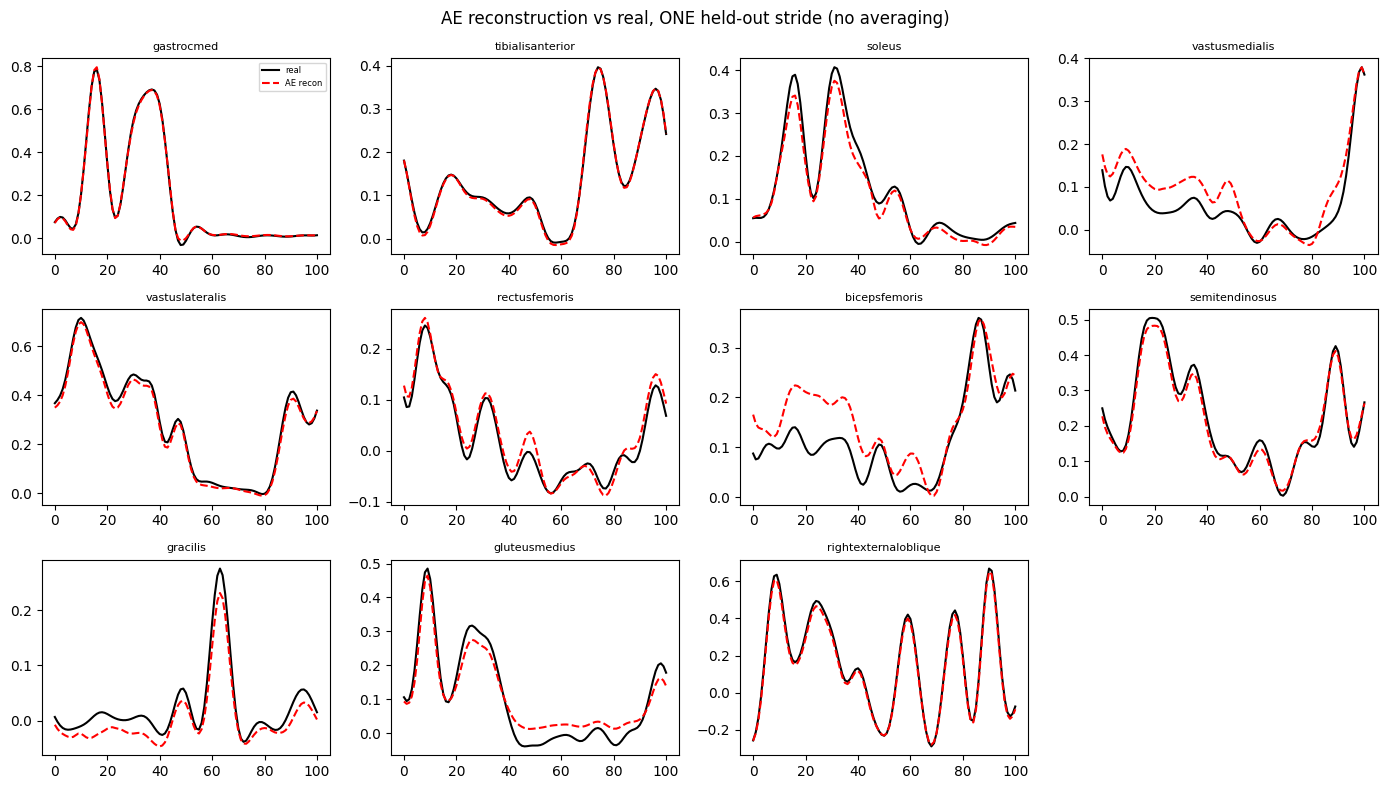

In [37]:
stride_i = 0
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for c in range(11):
    ax = axes.flat[c]
    ax.plot(strides_val[stride_i, :, c], color="black", label="real")
    ax.plot(recon_strides[stride_i, :, c], color="red", linestyle="--", label="AE recon")
    ax.set_title(EMG_CHANNELS[c], fontsize=8)
axes.flat[0].legend(fontsize=6)
axes.flat[-1].axis("off")
fig.suptitle("AE reconstruction vs real, ONE held-out stride (no averaging)")
fig.tight_layout()
plt.show()

In [ ]:
ae_small_ln_table

## Final Table

In [39]:
for name, t in [("pca_table", pca_table), ("nmf_table", nmf_table), ("ica_table", ica_table),
                  ("pca_tm_table", pca_tm_table), ("nmf_tm_table", nmf_tm_table), ("ica_tm_table", ica_tm_table)]:
      print(name, t.shape)

pca_table (11, 3)
nmf_table (11, 3)
ica_table (11, 3)
pca_tm_table (11, 3)
nmf_tm_table (11, 3)
ica_tm_table (11, 3)


In [ ]:
summary_all_modes = pd.DataFrame({
    "PCA": pca_table.set_index("K")["held_out_R2"].values,
    "NMF": nmf_table.set_index("K")["held_out_R2"].values,
    "ICA": ica_table.set_index("K")["held_out_R2"].values,
    "AE":  ae_table["held_out_R2"].values,
}, index=range(1, 12)).T
summary_all_modes.columns = [f"K={k}" for k in range(1, 12)]
summary_all_modes.index.name = "method"
summary_all_modes


In [ ]:
summary_treadmill = pd.DataFrame({
    "PCA": pca_tm_table.set_index("K")["held_out_R2"].values,
    "NMF": nmf_tm_table.set_index("K")["held_out_R2"].values,
    "ICA": ica_tm_table.set_index("K")["held_out_R2"].values,
    "AE":  ae_tm_table["held_out_R2"].values,
}, index=range(1, 12)).T
summary_treadmill.columns = [f"K={k}" for k in range(1, 12)]
summary_treadmill.index.name = "method"
summary_treadmill


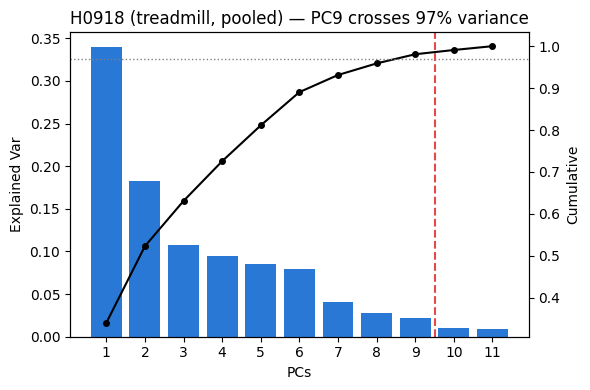

In [42]:
explained = pca_tm.explained_variance_ratio_
cumulative = np.cumsum(explained)
k_97 = np.argmax(cumulative >= 0.97) + 1   # first PC index crossing 97%

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 12), explained, color="#2a78d6")
ax2 = ax.twinx()
ax2.plot(range(1, 12), cumulative, color="black", marker="o", markersize=4)
ax2.axhline(0.97, color="gray", linestyle=":", linewidth=1)
ax.axvline(k_97 + 0.5, color="#e34948", linestyle="--", linewidth=1.5)
ax.set_xlabel("PCs")
ax.set_ylabel("Explained Var")
ax2.set_ylabel("Cumulative")
ax.set_xticks(range(1, 12))   
ax.set_title(f"H0918 (treadmill, pooled) — PC{k_97} crosses 97% variance")
fig.tight_layout()
plt.show()

In [ ]:
# Empirical comparison of latent_norm_penalty thresholds -- fixed K, treadmill
# pool. Checks both held-out R2 (did the penalty hurt reconstruction) and how
# close real strides' latent codes sit to an edge (did it actually do anything).
K_DIAG = 6

rows = []
for thresh in [0.7, 0.8, 0.9]:
    model = train_ae(X_train_tm_u_sub, dim_latent=K_DIAG, penalty_threshold=thresh)
    model.eval()
    with torch.no_grad():
        val_hat_u, val_al = model(torch.from_numpy(X_val_tm_u))
    val_hat = from_unit_tm(val_hat_u.numpy())
    edge_dist = torch.minimum(val_al, 1 - val_al)
    closeness = (1 - 2 * edge_dist).numpy()
    rows.append([
        thresh,
        r2(X_val_tm, val_hat),
        closeness.mean(),
        (closeness > 0.8).mean(),
        (closeness > 0.95).mean(),
    ])

threshold_diag = pd.DataFrame(rows, columns=["threshold", "held_out_R2", "mean_closeness", "frac_closeness>0.8", "frac_closeness>0.95"])
threshold_diag


In [1]:
import numpy as np
import pandas as pd
from leaps.synergy_common import load_split
from leaps.data.metadata import EMG_CHANNELS, ALL_MODES

strides_train, strides_val, meta_train, meta_val = load_split()

rows = []
for mode in ALL_MODES:
      X = strides_train[meta_train["modes"] == mode].reshape(-1, 11)
      for i, ch in enumerate(EMG_CHANNELS):
          col = X[:, i]
          rows.append([mode, ch, col.min(), col.max(), col.mean(), col.std(),
                       np.percentile(col, 1), np.percentile(col, 99)])

profile = pd.DataFrame(rows, columns=["mode", "muscle", "min", "max", "mean", "std", "p01", "p99"])
pd.set_option("display.width", 200)
profile.round(3)

,mode,muscle,min,max,mean,std,p01,p99
0,treadmill,gastrocmed,-0.092,3.693,0.240,0.348,-0.025,1.420
1,treadmill,tibialisanterior,-0.466,5.083,0.363,0.406,-0.104,1.702
2,treadmill,soleus,-0.468,4.773,0.268,0.381,-0.274,1.700
3,treadmill,vastusmedialis,-1.131,8.278,0.216,0.473,-0.768,2.230
4,treadmill,vastuslateralis,-0.807,7.249,0.202,0.381,-0.170,1.731
5,treadmill,rectusfemoris,-3.291,33.163,0.315,0.928,-1.812,3.308
6,treadmill,bicepsfemoris,-1.528,23.021,0.297,0.567,-0.071,2.338
7,treadmill,semitendinosus,-0.380,6.056,0.282,0.390,-0.041,1.659
8,treadmill,gracilis,-2.534,25.571,0.315,0.554,-0.105,2.165
9,treadmill,gluteusmedius,-0.240,9.440,0.266,0.324,-0.068,1.343


In [2]:
import numpy as np
import pandas as pd
from leaps.synergy_common import load_split
from leaps.data.metadata import EMG_CHANNELS, ALL_MODES

strides_train, strides_val, meta_train, meta_val = load_split()

rows = []
for mode in ALL_MODES:
      mode_strides = strides_train[meta_train["modes"] == mode]   # (n_strides, 101, 11)
      stride_means = mode_strides.mean(axis=1)                     # (n_strides, 11) -- one value per stride
      for i, ch in enumerate(EMG_CHANNELS):
          col = stride_means[:, i]
          rows.append([mode, ch, col.min(), col.max(), col.mean(), col.std(),
                       np.percentile(col, 1), np.percentile(col, 99)])

profile_per_stride = pd.DataFrame(rows, columns=["mode", "muscle", "min", "max", "mean", "std", "p01", "p99"])
pd.set_option("display.width", 200)
profile_per_stride.round(3)

,mode,muscle,min,max,mean,std,p01,p99
0,treadmill,gastrocmed,0.004,0.694,0.240,0.082,0.087,0.476
1,treadmill,tibialisanterior,0.012,1.440,0.363,0.196,0.079,0.974
2,treadmill,soleus,-0.318,0.951,0.268,0.128,-0.041,0.576
3,treadmill,vastusmedialis,-0.827,1.637,0.216,0.225,-0.574,0.922
4,treadmill,vastuslateralis,-0.190,1.139,0.202,0.140,-0.020,0.623
5,treadmill,rectusfemoris,-1.950,5.088,0.315,0.452,-1.545,2.215
6,treadmill,bicepsfemoris,-0.049,3.800,0.297,0.271,0.041,1.511
7,treadmill,semitendinosus,0.006,1.800,0.282,0.166,0.049,0.819
8,treadmill,gracilis,-0.290,3.386,0.315,0.253,0.028,1.195
9,treadmill,gluteusmedius,0.027,1.491,0.266,0.097,0.112,0.588


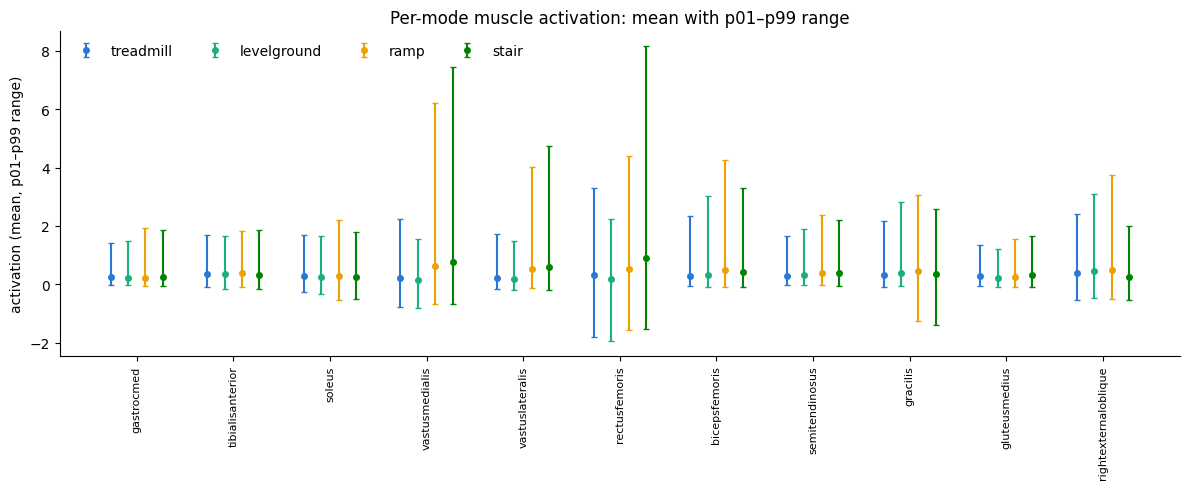

In [6]:
import numpy as np
import matplotlib.pyplot as plt

MODE_COLORS = {
      "treadmill": "#2a78d6",
      "levelground": "#1baf7a",
      "ramp": "#eda100",
      "stair": "#008300",
  }


fig, ax = plt.subplots(figsize=(12, 5))  
x = np.arange(len(EMG_CHANNELS))
width = 0.18

for j, mode in enumerate(ALL_MODES):
      sub = profile[profile["mode"] == mode].set_index("muscle").loc[EMG_CHANNELS]
      offset = (j - (len(ALL_MODES) - 1) / 2) * width
      ax.errorbar(
          x + offset, sub["mean"],
          yerr=[sub["mean"] - sub["p01"], sub["p99"] - sub["mean"]],
          fmt="o", markersize=4, elinewidth=1.5, capsize=2,
          color=MODE_COLORS[mode], ecolor=MODE_COLORS[mode], label=mode,
      )

ax.set_xticks(x)
ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=8)
ax.set_ylabel("activation (mean, p01\u2013p99 range)")
ax.set_title("Per-mode muscle activation: mean with p01\u2013p99 range")
ax.legend(frameon=False, ncol=4, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

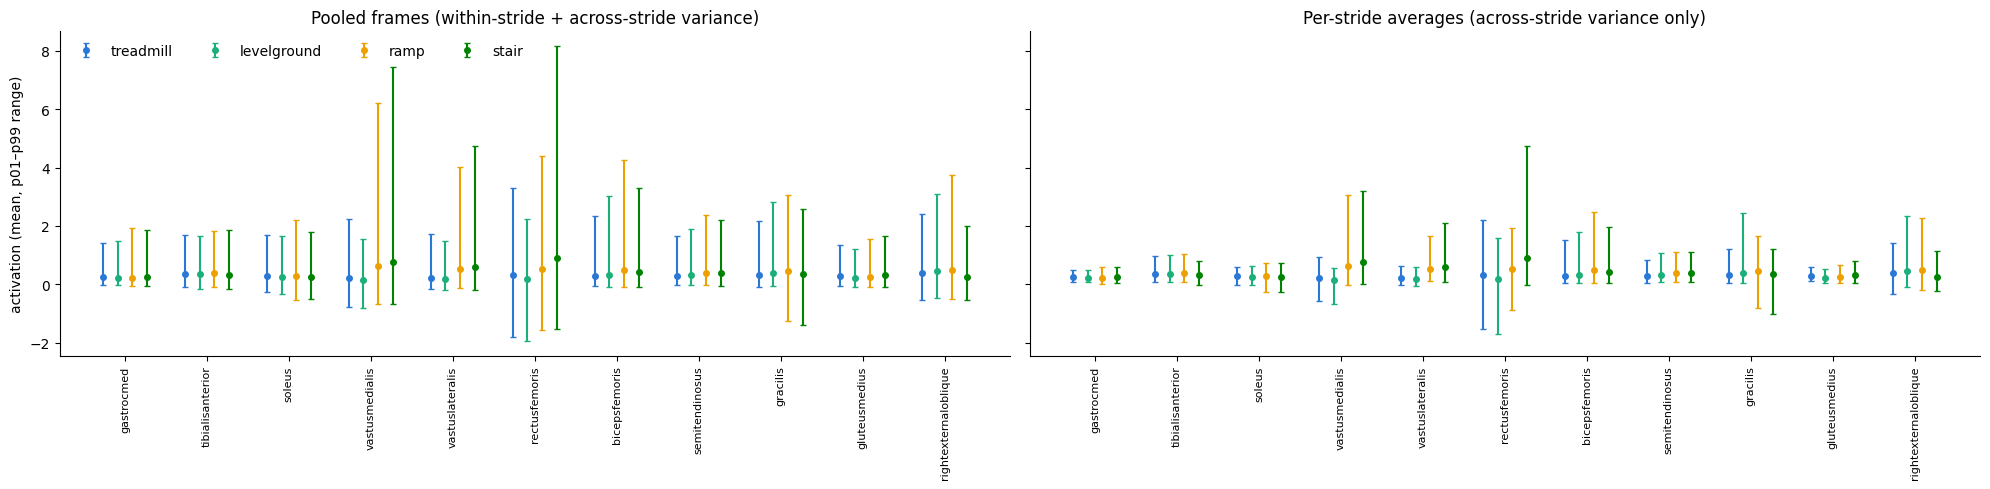

In [8]:
import numpy as np
import matplotlib.pyplot as plt
  
MODE_COLORS = {
      "treadmill": "#2a78d6",
      "levelground": "#1baf7a",
      "ramp": "#eda100",
      "stair": "#008300",
  }

def plot_mode_profile(ax, profile_df, title):
      x = np.arange(len(EMG_CHANNELS))
      width = 0.18
      for j, mode in enumerate(ALL_MODES):
          sub = profile_df[profile_df["mode"] == mode].set_index("muscle").loc[EMG_CHANNELS]
          offset = (j - (len(ALL_MODES) - 1) / 2) * width
          ax.errorbar(
              x + offset, sub["mean"],
              yerr=[sub["mean"] - sub["p01"], sub["p99"] - sub["mean"]],
              fmt="o", markersize=4, elinewidth=1.5, capsize=2,
              color=MODE_COLORS[mode], ecolor=MODE_COLORS[mode], label=mode,
          )
      ax.set_xticks(x)
      ax.set_xticklabels(EMG_CHANNELS, rotation=90, fontsize=8)
      ax.set_title(title)
      ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
plot_mode_profile(axes[0], profile, "Pooled frames (within-stride + across-stride variance)")
plot_mode_profile(axes[1], profile_per_stride, "Per-stride averages (across-stride variance only)")
axes[0].set_ylabel("activation (mean, p01\u2013p99 range)")
axes[0].legend(frameon=False, ncol=4, loc="upper left")
fig.tight_layout()
plt.show()